# Projet "Calibration de modèles" : Reseaux DNN pour la calibration d'un modele de Heston

#### Mathis Ribordy, Clément Rougeron

# Contexte et présentation du modèle de Heston

Historiquement, le modèle de Black-Scholes a posé les bases de l'évaluation des options, mais il suppose une volatilité constante qui ne reflète pas la réalité des marchés. À l'inverse, l'approche de Heston permet de capturer un niveau de volatilité variable, la présence de skew et une structure par terme beaucoup plus réaliste.

Sous la mesure risque-neutre, la dynamique du prix du sous-jacent $S_t$ et de sa variance $v_t$ est régie par le système d'équations différentielles stochastiques suivant :

$$dS_t = r S_t dt + \sqrt{v_t} S_t dW^1_t$$

$$dv_t = \kappa (\theta - v_t) dt + \sigma \sqrt{v_t} dW^2_t$$

Ce modèle repose sur cinq paramètres fondamentaux qu'il est nécessaire d'estimer :

* $v_0$ : la variance initiale.
* $\kappa$ : la vitesse de retour à la moyenne de la variance.
* $\theta$ : le niveau de variance à long terme.
* $\sigma$ : la volatilité de la volatilité (qui contrôle la courbure du smile).
* $\rho$ : le coefficient de corrélation entre les deux mouvements browniens $W^1$ et $W^2$.

La calibration de ces paramètres est un problème inverse mal posé mais indispensable. L'objectif est de trouver la combinaison exacte de ces cinq variables qui permet au modèle théorique de reproduire le plus fidèlement possible une surface de volatilités implicites observée sur le marché. Traditionnellement, cette étape repose sur des méthodes d'optimisation numérique qui peuvent s'avérer lentes et numériquement instables face à la complexité de la fonction caractéristique du modèle.

Pour surmonter ces limites de temps de calcul et de stabilité, ce projet propose une approche basée sur le Deep Learning, structurée en quatre étapes :

- Génération de données synthétiques: Nous construisons un ensemble d'apprentissage composé de surfaces de volatilité générées à partir de paramètres aléatoires, tout en veillant à respecter les contraintes physiques du modèle comme la condition de Feller ($2\kappa\theta > \sigma^2$).
- Entraînement des réseaux de neurones (DNN): Nous entraînons un modèle de calibration (qui traduit une surface en paramètres) et un générateur bidirectionnel, en utilisant une architecture résiduelle (ResNet) pour capter la relation non linéaire entre les prix et les paramètres.
- Validation: Les prédictions du réseau sont validées en recalculant la surface à l'aide d'un pricer semi-analytique de Heston basé sur une quadrature de Gauss-Legendre.
- Application sur données réelles: Le pipeline est finalement éprouvé sur des données de marché (options de l'indice s&p500 extraites via `yfinance`).

In [322]:
import time
import warnings
from datetime import datetime

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import tensorflow as tf
import yfinance as yf
from scipy.interpolate import griddata
from scipy.stats import norm as sp_norm
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.layers import (
    Activation,
    Add,
    BatchNormalization,
    Dense,
    Dropout,
    Input,
)
from tensorflow.keras.models import Model

warnings.filterwarnings("ignore")  # masque les alertes

# Fixer les graines pour rendre les experiences reproductibles.
np.random.seed(2026)  # graine numpy
tf.random.set_seed(2026)  # graine tensorflow

print(f"TensorFlow version: {tf.__version__}")  # version runtime


TensorFlow version: 2.21.0


# Grille de calibration et pricer Heston

La calibration du modèle de Heston consiste à trouver le jeu de paramètres optimaux permettant de reproduire les cotations observées sur le marché. Plutôt que de minimiser l'erreur directement sur les prix des options, nous nous baserons sur les surfaces de volatilité implicite de Black-Scholes. En effet, bien que les options soient négociées à un certain prix sur le marché, nous justifions ce choix par deux raisons:

- Le problème de l'échelle des valeurs: les prix des options s'étalent sur plusieurs ordres de grandeur. Une option profondément dans la monnaie (ITM) peut valoir des dizaines d'euros, tandis qu'une option très en dehors de la monnaie (OTM) ne vaudra que quelques centimes. Si l'on minimisait l'erreur (MSE) directement sur les prix, le DNN concentrerait tous ses efforts sur les options ITM pour réduire l'erreur absolue, ignorant totalement les options OTM qui contiennent pourtant des informations sur les risques extrêmes.
- La normalisation: la volatilité implicite agit comme une métrique de normalisation. Elle ramène toutes les options, quels que soient leur strike ou leur maturité, sur une échelle comparable et restreinte. Un réseau de neurones apprend beaucoup plus efficacement sur des données homogènes et standardisées.

Ensuite, pour qu'un réseau de neurones (DNN) apprenne à résoudre ce problème inverse complexe (passer d'une surface de volatilité à 5 paramètres), il a besoin d'une quantité massive d'exemples. Les données historiques de marché nous étant innacéssibles, nous générons un jeu de données synthétiques. Cette approche garantit que le réseau s'entraîne sur un univers suffisament riche, couvrant des combinaisons de paramètres variées, tout en filtrant les régimes numériquement instables ou économiquement peu crédibles (en imposant notamment la condition de Feller).

Enfin, et pour faire fonctionner cette approche par apprentissage profond, nous avons besoin d'un outil de valorisation capable de faire le pont entre un jeu de paramètres théoriques et une surface d'options. Ce moteur de calcul doit remplir deux rôles:
- D'une part, il est indispensable pour simuler et générer massivement les surfaces exactes qui constitueront notre base d'apprentissage. 
- D'autre part, il est le garant de notre validation: une fois le réseau entraîné, la seule façon de juger sa véritable performance est de prendre les paramètres qu'il a prédits, de recalculer la surface correspondante, et de mesurer l'erreur réelle de restitution (le repricing) par rapport au marché.

C'est précisément pour répondre à ces besoins que nous utiliserons un pricer semi-analytique de Heston. Cet algorithme repose sur l'évaluation de la fonction caractéristique du modèle et à une intégration numérique par quadrature de Gauss-Legendre.

## Grille de calibration et conventions

Nous travaillons sur une grille fixe de moneyness `K/S0` et de maturites `T`, avec un spot normalise `S0=1` pour isoler la dynamique de volatilite implicite.

In [323]:
moneyness_levels = np.linspace(0.5, 1.5, 11)  # ratios de strike
maturities = np.linspace(0.1, 2.0, 8)  # maturites
risk_free_rate = 0.02  # taux sans risque
spot_reference = 1.0  # spot de ref.


## Quadrature de Gauss-Legendre

Le prix semi-analytique de Heston repose sur une integration numerique. Nous discretisons cette integrale avec une quadrature de Gauss-Legendre, ce qui permet un bon compromis entre precision et temps de calcul.


In [324]:
# Quadrature de Gauss-Legendre pre-calculee.
num_quad_points = 48  # taille quadrature
u_max = 50.0  # borne integration
_x_gl, _w_gl = np.polynomial.legendre.leggauss(num_quad_points)  # noeuds
phi_points = 0.5 * (_x_gl + 1) * u_max  # noeuds echelles
phi_weights = _w_gl * u_max / 2  # poids echelles

print(
    "Grille de volatilite : "
    f"{len(moneyness_levels)} strikes x {len(maturities)} maturites = "
    f"{len(moneyness_levels) * len(maturities)} points"
)  # taille grille
print(
    f"Quadrature : {num_quad_points} points de Gauss-Legendre sur [0, {u_max}]"
)  # quadrature


Grille de volatilite : 11 strikes x 8 maturites = 88 points
Quadrature : 48 points de Gauss-Legendre sur [0, 50.0]


## Fonction caracteristique de Heston

La formule fermee de Heston s'exprime via une fonction caracteristique complexe. C'est le coeur du pricer semi-analytique.

La fonction caractéristique $f_j(\phi)$ évaluée au point $\phi$ s'écrit :

$$f_j(\phi) = \exp\left(C + D v_0 + i \phi \ln(S_0)\right)$$

Pour simplifier l'écriture, on définit les constantes suivantes selon que l'on calcule $P_1$ ou $P_2$ :
* Pour $j=1$ : $u_1 = \frac{1}{2}$ et $b_1 = \kappa - \rho \sigma$
* Pour $j=2$ : $u_2 = -\frac{1}{2}$ et $b_2 = \kappa$

Les termes intermédiaires se calculent ensuite ainsi :

$$d = \sqrt{(\rho \sigma \phi i - b_j)^2 - \sigma^2 (2 u_j \phi i - \phi^2)}$$

$$g = \frac{b_j - \rho \sigma \phi i - d}{b_j - \rho \sigma \phi i + d}$$

Les fonctions $C$ et $D$, qui dépendent du temps à l'échéance $T$, sont données par :

$$C = r \phi i T + \frac{\kappa \theta}{\sigma^2} \left[ (b_j - \rho \sigma \phi i - d) T - 2 \ln\left(\frac{1 - g e^{-d T}}{1 - g}\right) \right]$$

$$D = \frac{b_j - \rho \sigma \phi i - d}{\sigma^2} \left( \frac{1 - e^{-d T}}{1 - g e^{-d T}} \right)$$


In [325]:
def heston_cf_j(phi, maturity, v0, kappa, theta, sigma_v, rho, r, j):
    """
    Fonction caracteristique de Heston pour Pj (j=1 ou 2).
    Formulation stable d'Albrecher et al. (2007).
    phi: array de points de quadrature.
    """
    u_j = 0.5 if j == 1 else -0.5  # terme amorti
    b_j = (kappa - rho * sigma_v) if j == 1 else kappa  # terme derive
    a = kappa * theta  # prod retour

    d = np.sqrt(  # discriminant
        (rho * sigma_v * phi * 1j - b_j) ** 2
        - sigma_v**2 * (2 * u_j * phi * 1j - phi**2)
    )
    g = (  # ratio stable
        b_j - rho * sigma_v * phi * 1j - d
    ) / (b_j - rho * sigma_v * phi * 1j + d)
    exp_neg_dt = np.exp(-d * maturity)  # discr. actualise

    coeff_c = (  # coeff c
        r * phi * 1j * maturity
        + (a / sigma_v**2)
        * (
            (b_j - rho * sigma_v * phi * 1j - d) * maturity
            - 2 * np.log((1 - g * exp_neg_dt) / (1 - g))
        )
    )
    coeff_d = (  # coeff d
        (b_j - rho * sigma_v * phi * 1j - d)
        / sigma_v**2
        * (1 - exp_neg_dt)
        / (1 - g * exp_neg_dt)
    )

    return np.exp(  # fct caracteristique
        coeff_c + coeff_d * v0 + 1j * phi * np.log(spot_reference)
    )


## Du pricer Heston au prix de call

Une fois les fonctions caractéristiques $f_1(\phi)$ et $f_2(\phi)$ définies, nous devons revenir dans l'espace des prix pour évaluer l'option. Le prix d'un Call européen dans le modèle de Heston ressemble fortement à la formule de Black-Scholes, à la différence que les probabilités $P_1$ et $P_2$ intègrent la dynamique stochastique de la volatilité. 

Le prix du Call $C$ de strike $K$ et de maturité $T$ s'écrit :

$$C(S_0, K, T) = S_0 P_1 - K e^{-rT} P_2$$

Les termes $P_1$ et $P_2$ représentent les probabilités (ajustées de la prime de risque pour $P_1$) que l'option termine dans la monnaie. Contrairement à Black-Scholes où ces probabilités sont données par la fonction de répartition de la loi normale, elles sont ici obtenues par l'inversion de la fonction caractéristique via l'intégrale de Gil-Pelaez :

$$P_j = \frac{1}{2} + \frac{1}{\pi} \int_{0}^{\infty} \text{Re} \left( \frac{e^{-i \phi \ln(K)} f_j(\phi)}{i \phi} \right) d\phi \quad \text{pour } j \in \{1, 2\}$$

Dans notre implémentation, cette intégrale impropre est calculée numériquement. Nous la tronquons à une borne supérieure (ici $U_{\max} = 50$) et utilisons une discrétisation par quadrature de Gauss-Legendre (sur 48 points).

In [326]:
def heston_call_prices_vec(
    strike_array,
    maturity,
    v0,
    kappa,
    theta,
    sigma_v,
    rho,
    r=risk_free_rate,
):
    """
    Prix de calls europeens Heston, vectorise sur les strikes.
    strike_array: array de strikes (shape: n_strikes).
    Retourne: array de prix (shape: n_strikes).
    """
    phi = phi_points  # reutilise noeuds
    weights = phi_weights  # reutilise poids
    log_strike = np.log(strike_array)  # strikes en log
    prices = np.zeros(len(strike_array))  # prix sortie

    for j in [1, 2]:  # probas Heston
        f_j = heston_cf_j(
            phi,
            maturity,
            v0,
            kappa,
            theta,
            sigma_v,
            rho,
            r,
            j,
        )
        exp_factor = np.exp(  # phase Fourier
            -1j * phi[:, None] * log_strike[None, :]
        )
        integrand = np.real(  # partie reelle
            exp_factor * f_j[:, None] / (1j * phi[:, None])
        )
        probability_j = 0.5 + (  # integration
            1 / np.pi
        ) * np.sum(weights[:, None] * integrand, axis=0)

        if j == 1:  # ajoute spot
            prices += spot_reference * probability_j
        else:  # retire strike
            prices -= strike_array * np.exp(-r * maturity) * probability_j

    return np.maximum(prices, 1e-15)  # prix positifs


## Inversion Black-Scholes et volatilite implicite

Pour comparer le modele de Heston au marche, nous convertissons les prix de calls en volatilites implicites Black-Scholes.


In [327]:
def bs_call(spot, strike, maturity, r, sigma):
    """Prix Black-Scholes d'un call europeen (vectorise)."""
    d1 = (  # calcule d1
        np.log(spot / strike) + (r + 0.5 * sigma**2) * maturity
    ) / (sigma * np.sqrt(maturity))
    d2 = d1 - sigma * np.sqrt(maturity)  # calcule d2
    return (  # prix Black-Scholes
        spot * sp_norm.cdf(d1)
        - strike * np.exp(-r * maturity) * sp_norm.cdf(d2)
    )


def bs_vega(spot, strike, maturity, r, sigma):
    """Vega Black-Scholes (vectorise)."""
    d1 = (  # reutilise d1
        np.log(spot / strike) + (r + 0.5 * sigma**2) * maturity
    ) / (sigma * np.sqrt(maturity))
    return spot * np.sqrt(maturity) * sp_norm.pdf(d1)  # vega


In [328]:
def newton_iv(prices, spot, strike, maturity, r, n_iter=50, tol=1e-8):
    """Volatilite implicite par Newton-Raphson (vectorise)."""
    sigma = np.full_like(prices, 0.3)  # point initial

    for _ in range(n_iter):  # itere Newton
        bs_prices = bs_call(  # tarifie options
            spot,
            strike,
            maturity,
            r,
            sigma,
        )
        vegas = bs_vega(  # sensibilites
            spot,
            strike,
            maturity,
            r,
            sigma,
        )
        diff = bs_prices - prices  # erreur prix
        update = np.where(  # vegas faibles
            vegas > 1e-12,
            diff / vegas,
            0.0,
        )
        sigma = sigma - update  # maj sigma
        sigma = np.clip(sigma, 0.005, 3.0)  # plage realiste
        if np.max(np.abs(diff)) < tol:  # critere arret
            break

    return sigma  # vols implicites


## Construction d'une surface complete de volatilite implicite

A partir d'un seul jeu de parametres Heston, nous calculons la surface complete de volatilite implicite sur toute la grille `(K/S0, T)`.


In [329]:
def compute_iv_surface(
    v0,
    kappa,
    theta,
    sigma_v,
    rho,
    r=risk_free_rate,
    spot=spot_reference,
):
    """
    Calcule la surface de volatilite implicite (88 points) pour un jeu
    de parametres Heston.
    Retourne un vecteur 1D de taille 88 (maturites x moneyness).
    """
    strikes = spot * moneyness_levels  # grille strike
    iv_surface = np.zeros(len(maturities) * len(moneyness_levels))

    for maturity_idx, maturity in enumerate(maturities):  # parcourt maturites
        prices = heston_call_prices_vec(
            strikes,
            maturity,
            v0,
            kappa,
            theta,
            sigma_v,
            rho,
            r,
        )
        ivs = newton_iv(prices, spot, strikes, maturity, r)  # inverse prix
        start = maturity_idx * len(moneyness_levels)  # debut bloc
        stop = (maturity_idx + 1) * len(moneyness_levels)  # fin bloc
        iv_surface[start:stop] = ivs  # ecrit le smile

    return iv_surface  # surface a plat


In [330]:
t0 = time.time()  # debut chrono
test_surface = compute_iv_surface(0.04, 2.0, 0.04, 0.3, -0.7)
t1 = time.time()  # fin chrono

print("\nTest du pricer Heston :")  # titre
print(f"  Temps de calcul : {(t1 - t0) * 1000:.1f} ms")  # timing
print(f"  Vol implicite ATM (maturity=1.0) : {test_surface[4 * 11 + 5]:.4f}")
print(  # min max iv
    f"  Min IV : {test_surface.min():.4f}, "
    f"Max IV : {test_surface.max():.4f}"
)
print(f"  Shape : {test_surface.shape}")  # shape sortie



Test du pricer Heston :
  Temps de calcul : 8.1 ms
  Vol implicite ATM (maturity=1.0) : 0.1941
  Min IV : 0.0050, Max IV : 0.5521
  Shape : (88,)


## Interpretation

Le test ci-dessus permet de verifier trois points :

- le temps de calcul reste compatible avec la generation de surfaces ;
- la volatilite ATM obtenue est d'un ordre de grandeur plausible ;
- la surface ne produit ni volatilites negatives ni valeurs aberrantes.


# Generation des donnees synthetiques

Pour constituer une base d'apprentissage pertinente, l'échantillonnage aléatoire des cinq paramètres de Heston s'effectue au sein de bornes suffisament bien définies.

- Ces intervalles continus ont été choisis pour refléter la dynamique d'un indice actions liquide, en imposant par exemple un effet de levier $\rho$ fortement négatif compris entre $-0.95$ et $-0.2$. 
- Aussi, afin de balayer uniformément les différents ordres de grandeur, le paramètre de vitesse de retour à la moyenne $\kappa$ est tiré selon une échelle logarithmique sur l'intervalle $[0.5, 8.0]$. 
- Enfin, chaque vecteur de paramètres généré subit un filtrage rigoureux (validation de la condition de Feller et contrôle du niveau de la volatilité à la monnaie) avant de calculer la surface associée.

## Choix des bornes de parametres

Les bornes sont choisies pour couvrir un regime plausible d'indice actions liquide, tout en evitant les regimes numeriquement instables ou economiquement peu credibles.


In [331]:
# Bornes des parametres Heston [v0, rho, sigma, theta, kappa]
# Elles couvrent des regimes calmes et des phases de stress.
# et proches de la frontiere de Feller, tout en restant numeriquement stables.
bounds = {  # fixe bounds
    'v0': (0.004, 0.16),  
    'rho': (-0.98, -0.15),
    'sigma': (0.04, 0.95),
    'theta': (0.008, 0.16),
    'kappa': (0.35, 9.0),  
}

param_order = ['v0', 'rho', 'sigma', 'theta', 'kappa']  # fixe param order

synthetic_data_config = {  # fixe synthetic data
    'num_samples': 16000,  
    'progress_step': 2000, 
}

synthetic_regimes = {  # fixe synthetic regi
    'core': { 
        'v0': (0.008, 0.08),  
        'theta': (0.012, 0.09),
        'kappa': (0.8, 5.0),  
        'rho': (-0.90, -0.30),
        'rho_beta': (2.2, 2.8),
        'feller_ratio': (0.55, 0.85),
    },
    'stress': {  
        'v0': (0.05, 0.16),  
        'theta': (0.04, 0.16),
        'kappa': (0.35, 2.5), 
        'rho': (-0.98, -0.55),
        'rho_beta': (1.6, 3.5),
        'feller_ratio': (0.80, 0.995),  
    },
    'high_skew': {  
        'v0': (0.008, 0.09),  
        'theta': (0.012, 0.10),
        'kappa': (0.6, 4.0),  
        'rho': (-0.98, -0.70),
        'rho_beta': (1.4, 4.0),
        'feller_ratio': (0.65, 0.92),
    },
    'fast_mean_reversion': {  
        'v0': (0.006, 0.10),  
        'theta': (0.010, 0.12),
        'kappa': (3.0, 9.0),  
        'rho': (-0.75, -0.15), 
        'rho_beta': (2.2, 2.2),
        'feller_ratio': (0.45, 0.78),  
    },
}

synthetic_regime_names = list(synthetic_regimes.keys())  # fixe synthetic regi
synthetic_regime_weights = np.array([0.45, 0.20, 0.20, 0.15], dtype=float)
synthetic_regime_weights = (  # fixe synthetic regi
    synthetic_regime_weights / synthetic_regime_weights.sum()  
)

training_config = {  # fixe config entrainement
    'calibration': {  
        'learning_rate': 7e-4,  
        'batch_size': 256,  
        'epochs': 600,  
        'val_split': 0.20,  
        'lr_patience': 12,  
        'stop_patience': 32,
    },
    'generator': { 
        'learning_rate': 8e-4,  
        'batch_size': 256,  
        'epochs': 400,  
        'val_split': 0.20,
        'lr_patience': 10, 
        'stop_patience': 24,
    },
}


## Echantillonnage des parametres

Le but n'est plus seulement d'obtenir des combinaisons plausibles de `v0`, `kappa`, `theta`, `sigma` et `rho`, mais d'exposer le reseau a plusieurs regimes de marche : un coeur de distribution relativement standard, des cas stresses a forte volatilite, des smiles tres asymetriques et des regimes de retour a la moyenne rapide. Cette diversification rend la phase d'apprentissage moins triviale et rapproche davantage les surfaces synthetiques des difficultes rencontrees sur des quotes de marche reelles.


In [332]:
def sample_log_uniform(low, high):
    """Echantillonne une variable positive en echelle logarithmique."""
    return float(np.exp(np.random.uniform(np.log(low), np.log(high))))


def sample_beta_range(low, high, alpha, beta):
    """Echantillonne sur [low, high] via une loi Beta."""
    return float(low + (high - low) * np.random.beta(alpha, beta))


def sample_heston_parameters():
    """Echantillonne un jeu de parametres sur plusieurs regimes plausibles."""
    regime_name = np.random.choice(  # tire un regime
        synthetic_regime_names,
        p=synthetic_regime_weights,
    )
    regime = synthetic_regimes[regime_name]  # lit le regime

    v0 = sample_log_uniform(*regime['v0'])  # echant v0
    theta = sample_log_uniform(*regime['theta'])  # echant theta
    kappa = sample_log_uniform(*regime['kappa'])  # echant kappa
    rho = sample_beta_range(*regime['rho'], *regime['rho_beta'])  # echant rho
    sigma_scale = np.random.uniform(*regime['feller_ratio'])
    sigma = np.sqrt(2.0 * kappa * theta) * sigma_scale  # echant sigma
    sigma = np.clip(sigma, *bounds['sigma'])  # borne sigma

    return regime_name, v0, rho, sigma, theta, kappa  # un echantillon


## Filtrage des surfaces synthetiques

Nous imposons la condition de Feller et des controles de qualite sur la surface complete ainsi que sur la courbe ATM. Cela evite d'entrainer le DNN sur des exemples peu exploitables.


In [333]:
def generate_synthetic_data(num_samples=synthetic_data_config['num_samples']):
    """
    Genere des surfaces Heston multi-regimes, avec davantage de cas
    difficiles.
    """
    params = []  # params retenus
    surfaces = []  # surfaces retenues
    n_rejected = 0  # compte rejets
    atm_idx = len(moneyness_levels) // 2  # colonne atm
    progress_step = synthetic_data_config['progress_step']  # pas rapport
    regime_counts = {name: 0 for name in synthetic_regime_names}

    while len(params) < num_samples:  # boucle echant
        sampled_params = sample_heston_parameters()  # tire params
        regime_name, v0, rho, sigma, theta, kappa = sampled_params
        surface = compute_iv_surface(  # tarifie surface
            v0,
            kappa,
            theta,
            sigma,
            rho,
        )

        if np.any(~np.isfinite(surface)):  # rejette instable
            n_rejected += 1  # compte rejet
            continue  # saute echantillon

        surface_matrix = surface.reshape(  # reforme surface
            len(maturities),
            len(moneyness_levels),
        )
        atm_curve = surface_matrix[:, atm_idx]  # courbe atm
        left_wing = surface_matrix[:, 1]  # aile gauche
        right_wing = surface_matrix[:, -2]  # aile droite
        surface_range = surface.max() - surface.min()  # amplitude
        average_skew = np.mean(left_wing - right_wing)  # skew

        if np.any(surface < 0.01) or np.any(surface > 1.0):
            n_rejected += 1  # compte rejet
            continue  # saute surface
        if np.any(atm_curve < 0.04) or np.any(atm_curve > 0.75):
            n_rejected += 1  # compte rejet
            continue  # saute surface
        if regime_name != 'core' and surface_range < 0.025:
            n_rejected += 1  # compte rejet
            continue  # saute surface
        if regime_name in {'stress', 'high_skew'} and average_skew < 0.015:
            n_rejected += 1  # compte rejet
            continue  # saute surface

        params.append([v0, rho, sigma, theta, kappa])  # stocke params
        surfaces.append(surface)  # stocke surface
        regime_counts[regime_name] += 1  # regime retenu

        if len(params) % progress_step == 0:  # avancement
            print(  # progression
                f"  Genere : {len(params)}/{num_samples} "
                f"(rejetes : {n_rejected})"
            )

    print(f"  Total rejetes (stabilite/filtrage) : {n_rejected}")
    print('  Repartition des regimes retenus :')  # resume regimes
    for name in synthetic_regime_names:  # parcourt regimes
        print(f"    {name:<20s}: {regime_counts[name]:5d}")  # total

    return np.array(params), np.array(surfaces)  # jeu de donnees


In [334]:
# Generation
print(  # jeu cible
    "Cible : "
    f"{synthetic_data_config['num_samples']} echantillons "
    "multi-regimes avec pricer Heston semi-analytique\n"
)
t0 = time.time()  # debut chrono
x_params, y_surfaces = generate_synthetic_data(  # genere donnees
    synthetic_data_config['num_samples']
)
t_gen = time.time() - t0  # temps generation

print(f"\nTemps de generation : {t_gen:.1f}s ({t_gen / 60:.1f} min)")
print(f'Shape params   : {x_params.shape}')  # shape params
print(f'Shape surfaces : {y_surfaces.shape}')  # shape surfaces


Cible : 16000 echantillons multi-regimes avec pricer Heston semi-analytique

  Genere : 2000/16000 (rejetes : 5060)
  Genere : 4000/16000 (rejetes : 10131)
  Genere : 6000/16000 (rejetes : 15630)
  Genere : 8000/16000 (rejetes : 20800)
  Genere : 10000/16000 (rejetes : 25966)
  Genere : 12000/16000 (rejetes : 30958)
  Genere : 14000/16000 (rejetes : 35896)
  Genere : 16000/16000 (rejetes : 41058)
  Total rejetes (stabilite/filtrage) : 41058
  Repartition des regimes retenus :
    core                :  3585
    stress              :  8756
    high_skew           :  2445
    fast_mean_reversion :  1214

Temps de generation : 352.4s (5.9 min)
Shape params   : (16000, 5)
Shape surfaces : (16000, 88)


In [335]:
# Separation apprentissage / test (80% / 20%)
split_idx = int(0.8 * len(x_params))  # fixe indice coupure
params_train, params_test = x_params[:split_idx], x_params[split_idx:]
surfaces_train, surfaces_test = y_surfaces[:split_idx], y_surfaces[split_idx:]

print(f"\nTrain size: {len(params_train)}, Test size: {len(params_test)}")



Train size: 12800, Test size: 3200


# Prétraitement

## Standardisation et rescaling

Avant de nourrir le réseau de neurones, une étape de prétraitement s'avère techniquement indispensable. En effet, les surfaces de volatilité implicite et les cinq paramètres du modèle de Heston n'ont absolument pas la même échelle. La variance initiale ou le niveau à long terme sont des valeurs très petites, tandis que la vitesse de retour à la moyenne peut être bien plus grande.

Sans ajustement préalable, cette forte disparité numérique risquerait de déséquilibrer l'apprentissage et d'empêcher la bonne optimisation des poids du réseau. Pour résoudre ce problème, nous appliquons d'abord une standardisation sur les surfaces pour les recentrer autour de zéro et lisser leur variance.

Aussi, nous appliquons un rescaling aux paramètres de Heston afin de les contraindre strictement dans l'intervalle $[-1, 1]$. Cette mise à l'échelle est cohérente puisqu'elle correspond parfaitement à la plage de sortie de la fonction d'activation $\tanh$ de notre calibrateur.

In [336]:
# Standardisation des surfaces de volatilite
surface_mean = np.mean(surfaces_train, axis=0)  # fixe surface mean
surface_std = np.std(surfaces_train, axis=0)  # fixe surface std
surface_std = np.where(surface_std < 1e-6, 1e-6, surface_std)

x_train_scaled = (surfaces_train - surface_mean) / surface_std
x_test_scaled = (surfaces_test - surface_mean) / surface_std


In [337]:
# Mise a l'echelle des parametres dans [-1, 1]
param_mins = (  # fixe param mins
    np.array([bounds[k][0] for k in ['v0', 'rho', 'sigma', 'theta', 'kappa']])
)
param_maxs = (  # fixe param maxs
    np.array([bounds[k][1] for k in ['v0', 'rho', 'sigma', 'theta', 'kappa']])
)


def scale_params(p):  
    # Formule : 2 * ((p - p_min) / (p_max - p_min) - 0.5)
    return 2 * ((p - param_mins) / (param_maxs - param_mins) - 0.5)  # retourne


def unscale_params(p_scaled):  
    return (p_scaled / 2 + 0.5) * (param_maxs - param_mins) + param_mins


In [338]:
y_train_scaled = scale_params(params_train)  # fixe y train scaled
y_test_scaled = scale_params(params_test)  # fixe y test scaled


# Visualisation du dataset généré

Nous vérifions que la base générée couvre bien l'espace des parametres et produit des surfaces variees.


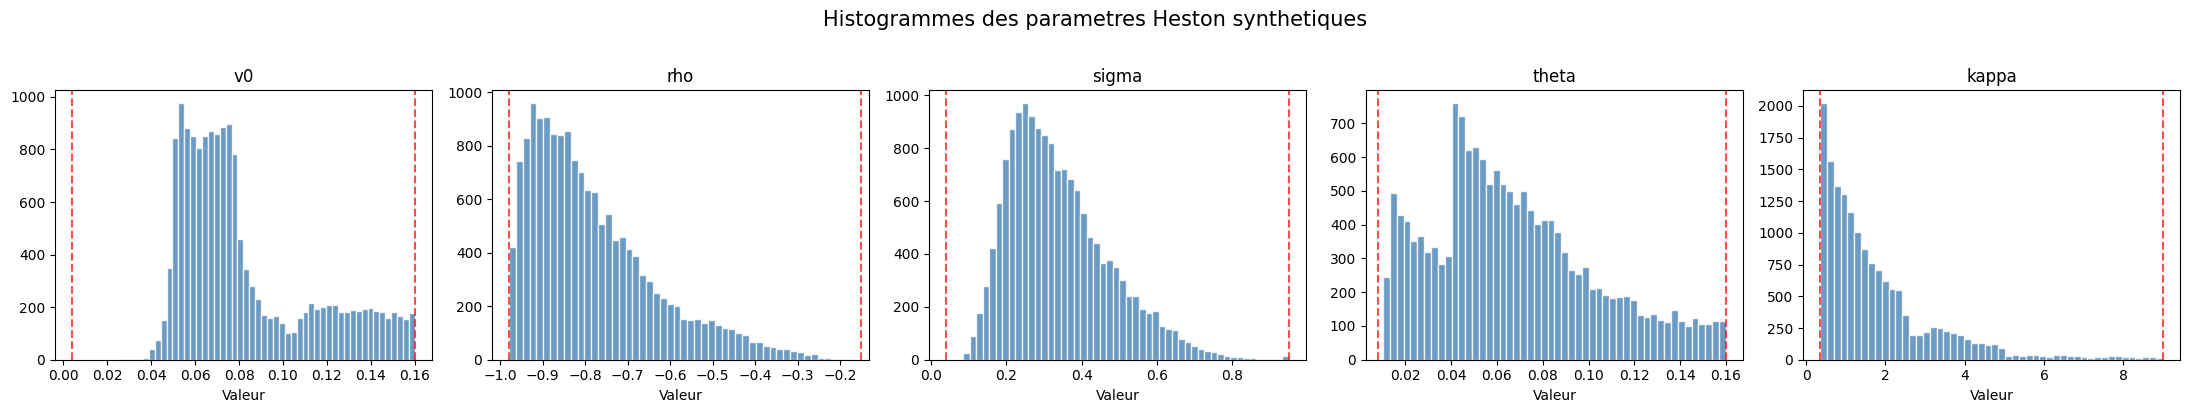

In [339]:
fig, axes = plt.subplots(1, 5, figsize=(22, 4))  

for name, ax in zip(param_order, axes): 
    values = x_params[:, param_order.index(name)]  
    ax.hist(values, bins=50, color='steelblue', edgecolor='white', alpha=0.8)
    lo, hi = bounds[name]  
    ax.axvline(lo, color='red', linestyle='--', alpha=0.7)  
    ax.axvline(hi, color='red', linestyle='--', alpha=0.7) 
    ax.set_title(name, fontsize=12)  
    ax.set_xlabel('Valeur') 

plt.suptitle(  
    'Histogrammes des parametres Heston synthetiques', 
    fontsize=15, 
    y=1.02, 
)
plt.tight_layout()  
plt.show()  


## Interprétation des histogrammes

L'analyse des histogrammes confirme que les bornes de nos paramètres sont suffisamment visitées et qu'il n'y a pas de concentration excessive sur les bords. Cette dispersion globale valide le calibrage de notre domaine de définition et garantit que le réseau s'entraîne sur des données variées.

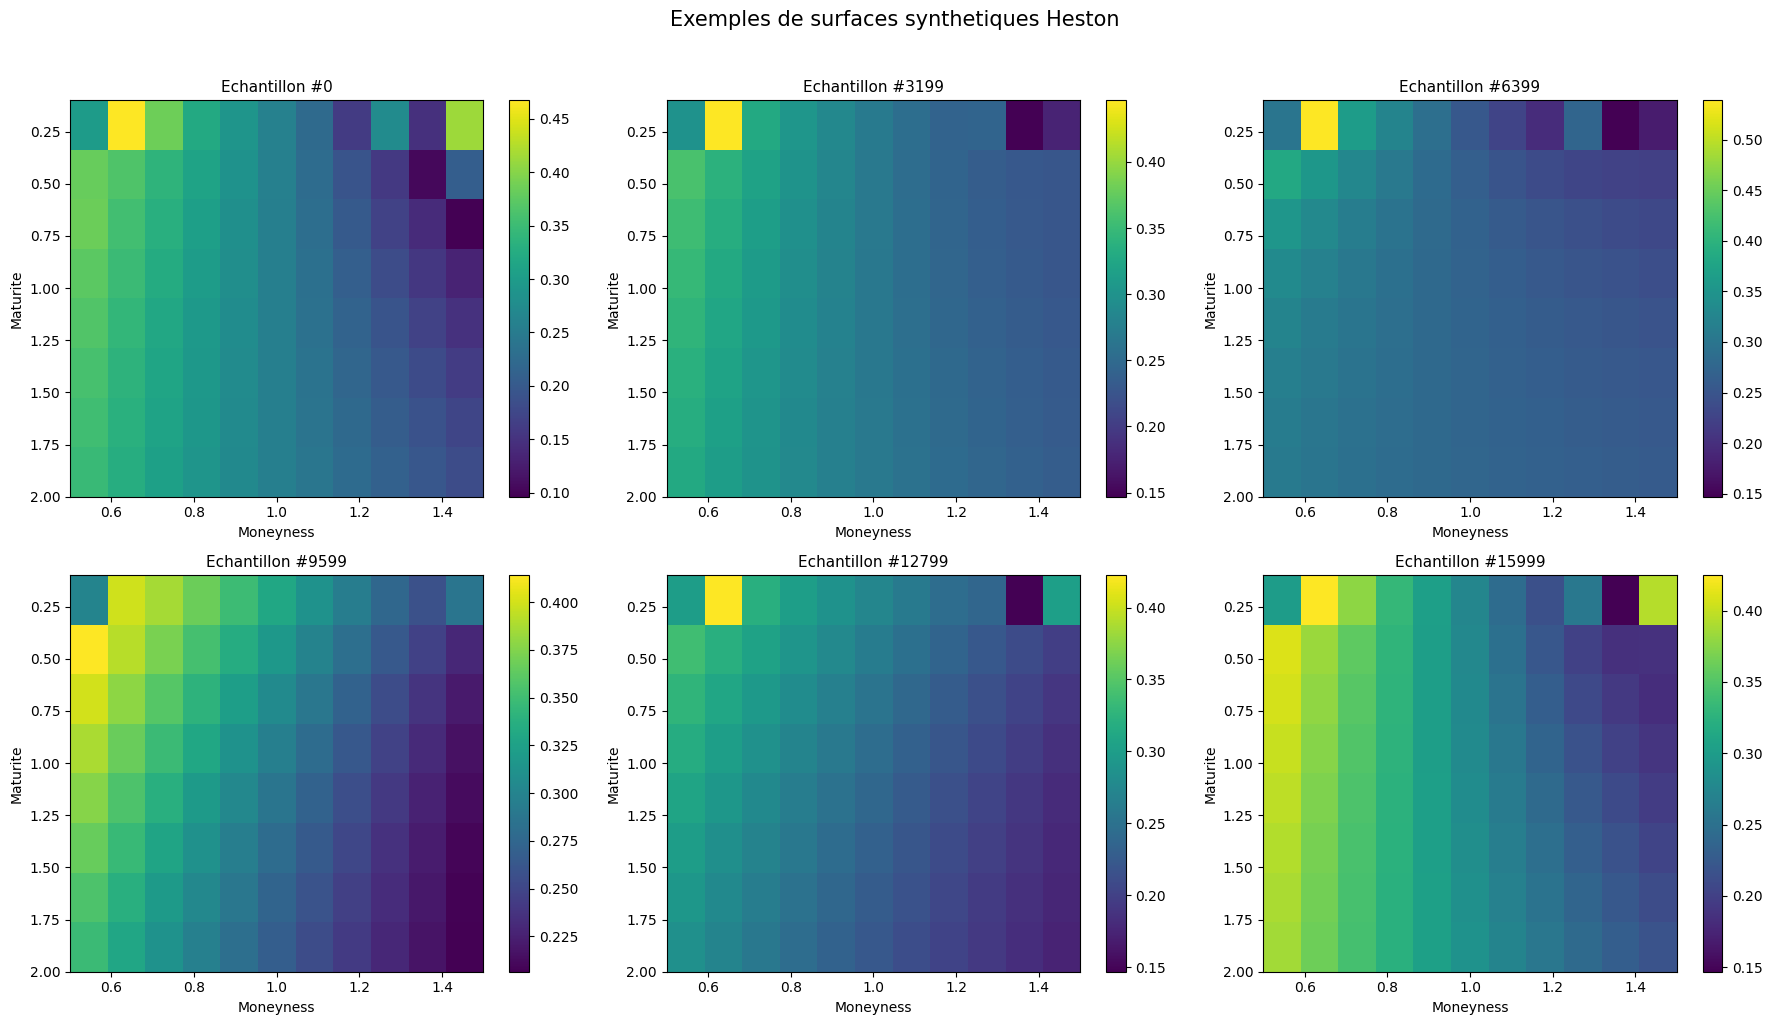

In [340]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))  # grille figure
flat_axes = axes.flatten()  # aplatit axes
sample_indices = np.linspace(  # echantillons rep
    0,
    len(y_surfaces) - 1,
    num=len(flat_axes),
    dtype=int,
)

for sample_idx, ax in zip(sample_indices, flat_axes):  # parcourt echant.
    surface = y_surfaces[sample_idx].reshape(  # reforme surface
        len(maturities),
        len(moneyness_levels),
    )
    im = ax.imshow(  # surface exemple
        surface,
        aspect='auto',
        cmap='viridis',
        extent=[
            moneyness_levels[0],
            moneyness_levels[-1],
            maturities[-1],
            maturities[0],
        ],
    )
    ax.set_title(f'Echantillon #{sample_idx}', fontsize=11)  # nom echant.
    ax.set_xlabel('Moneyness')  # axe x
    ax.set_ylabel('Maturite')  # axe y
    plt.colorbar(im, ax=ax)  # barre couleur

plt.suptitle(  # titre figure
    'Exemples de surfaces synthetiques Heston',
    fontsize=15,
    y=1.02,
)
plt.tight_layout()  # vue serree
plt.show()  # affiche figure


## Interprétation des surfaces synthétiques

Comme on peut l'observer sur ces figures, nos surfaces générées font bien apparaître simultanément un niveau moyen de volatilité distinct, une asymétrie gauche-droite (le skew) et une structure par terme selon les maturités.

# Architecture du réseau 

## Le Calibrateur DNN

Le calibrateur est le cœur de notre approche d'inversion. Il prend en entrée une surface de volatilité implicite aplatie (un vecteur de 88 points correspondant à notre grille fixe de moneyness et de maturités) et renvoie les 5 paramètres du modèle de Heston. 

Pour capturer la relation hautement non linéaire qui lie la forme géométrique du smile à la dynamique stochastique sous-jacente, nous avons opté pour une architecture neuronale de type ResNet. Le réseau empile plusieurs blocs résiduels (qui incluent des connexions shortcut) pour faciliter la propagation du gradient. Ces blocs intègrent des couches Denses, de la normalisation par lot (Batch Normalization) pour accélérer et stabiliser la convergence, des activations ELU, ainsi que du Dropout pour limiter le surapprentissage. 

Enfin, la couche de sortie utilise judicieusement une fonction d'activation $\tanh$, pour garantir que les cinq paramètres prédits tombent exactement dans l'espace normalisé $[-1, 1]$ défini lors de notre étape de prétraitement.

In [341]:
def residual_block(x, units, dropout_rate=0.2):  
    """Bloc residuel avec BatchNorm, ELU et Dropout."""
    shortcut = x  # fixe shortcut

    h = Dense(units, kernel_initializer='he_normal')(x)  
    h = BatchNormalization()(h)  
    h = Activation('elu')(h)  
    h = Dropout(dropout_rate)(h) 

    h = Dense(units, kernel_initializer='he_normal')(h)  
    h = BatchNormalization()(h)  

    if shortcut.shape[-1] != units:  
        shortcut = Dense(units, kernel_initializer='he_normal')(shortcut)

    h = Add()([h, shortcut])  
    h = Activation('elu')(h)  
    return h 


In [342]:
def build_calibration_model(input_dim=88, output_dim=5): 
    """
    Modele de calibration : Surface de volatilite (88) -> Parametres
    Heston (5).
    Architecture ResNet elargie pour exploiter un jeu synthetique plus riche.
    """
    inputs = Input(shape=(input_dim,), name='vol_surface')

    x = Dense(192, kernel_initializer='he_normal')(inputs)
    x = BatchNormalization()(x)
    x = Activation('elu')(x)
    x = Dropout(0.15)(x)

    x = residual_block(x, 128, dropout_rate=0.15)
    x = residual_block(x, 128, dropout_rate=0.15)
    x = residual_block(x, 64, dropout_rate=0.15)

    x = Dense(64, kernel_initializer='he_normal')(x)
    x = BatchNormalization()(x)
    x = Activation('elu')(x)

    outputs = Dense(output_dim, activation='tanh', name='heston_params')(x)

    model = Model(inputs=inputs, outputs=outputs, name='Calibration_DNN')
    return model

calibration_model = build_calibration_model()
calibration_model.summary()


Model: "Calibration_DNN"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ vol_surface         │ (None, 88)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_56 (Dense)    │ (None, 192)       │     17,088 │ vol_surface[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 192)       │        768 │ dense_56[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_45       │ (None, 192)       │          0 │ batch_normalizat… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_23          │ (None, 192)       │          0 │ activation_45[0]… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_57 (Dense)    │ (None, 128)       │     24,704 │ dropout_23[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128)       │        512 │ dense_57[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_46       │ (None, 128)       │          0 │ batch_normalizat… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_24          │ (None, 128)       │          0 │ activation_46[0]… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_58 (Dense)    │ (None, 128)       │     16,512 │ dropout_24[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128)       │        512 │ dense_58[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_59 (Dense)    │ (None, 128)       │     24,704 │ dropout_23[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_17 (Add)        │ (None, 128)       │          0 │ batch_normalizat… │
│                     │                   │            │ dense_59[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_47       │ (None, 128)       │          0 │ add_17[0][0]      │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_60 (Dense)    │ (None, 128)       │     16,512 │ activation_47[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128)       │        512 │ dense_60[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_48       │ (None, 128)       │          0 │ batch_normalizat… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_25          │ (None, 128)       │          0 │ activation_48[0]… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 144,773 (565.52 KB)

 Trainable params: 142,981 (558.52 KB)

 Non-trainable params: 1,792 (7.00 KB)

## Le Générateur bidirectionnel

À l'inverse du calibrateur, le réseau générateur prend en entrée les 5 paramètres du modèle de Heston et apprend à reconstruire la surface de volatilité correspondante (les 88 points de notre grille). Pour accomplir cette tâche, il s'appuie sur une architecture symétrique à celle du calibrateur, intégrant lui aussi des couches Denses, des normalisations par lot (Batch Normalization), des activations ELU, et des blocs résiduels.

Bien que ce générateur ne soit pas l'outil de valorisation final (ce rôle de validation étant strictement réservé au pricer semi-analytique de Heston), il joue un rôle de diagnostic interne. En créant une boucle d'évaluation `surface -> paramètres -> surface`, ce framework bidirectionnel permet de vérifier que les représentations latentes apprises par les réseaux sont robustes et cohérentes dans les deux sens du mapping. 


In [343]:
def build_generator_model(input_dim=5, output_dim=88):  
    """
    Modele generateur : Parametres Heston (5) -> Surface de volatilite (88).
    Architecture plus capacitaire pour suivre le calibrateur elargi.
    """
    inputs = Input(shape=(input_dim,), name='heston_params_in')

    x = Dense(64, kernel_initializer='he_normal')(inputs)
    x = BatchNormalization()(x)
    x = Activation('elu')(x)
    x = Dropout(0.15)(x)

    x = residual_block(x, 128, dropout_rate=0.15)
    x = residual_block(x, 128, dropout_rate=0.15)
    x = residual_block(x, 96, dropout_rate=0.10)

    x = Dense(192, kernel_initializer='he_normal')(x)
    x = BatchNormalization()(x)
    x = Activation('elu')(x)

    outputs = Dense(output_dim, name='vol_surface_out')(x)

    model = Model(inputs=inputs, outputs=outputs, name='Generator_DNN')
    return model

generator_model = build_generator_model()
generator_model.summary()


Model: "Generator_DNN"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ heston_params_in    │ (None, 5)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_66 (Dense)    │ (None, 64)        │        384 │ heston_params_in… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64)        │        256 │ dense_66[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_53       │ (None, 64)        │          0 │ batch_normalizat… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_27          │ (None, 64)        │          0 │ activation_53[0]… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_67 (Dense)    │ (None, 128)       │      8,320 │ dropout_27[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128)       │        512 │ dense_67[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_54       │ (None, 128)       │          0 │ batch_normalizat… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_28          │ (None, 128)       │          0 │ activation_54[0]… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_68 (Dense)    │ (None, 128)       │     16,512 │ dropout_28[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128)       │        512 │ dense_68[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_69 (Dense)    │ (None, 128)       │      8,320 │ dropout_27[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_20 (Add)        │ (None, 128)       │          0 │ batch_normalizat… │
│                     │                   │            │ dense_69[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_55       │ (None, 128)       │          0 │ add_20[0][0]      │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_70 (Dense)    │ (None, 128)       │     16,512 │ activation_55[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128)       │        512 │ dense_70[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_56       │ (None, 128)       │          0 │ batch_normalizat… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_29          │ (None, 128)       │          0 │ activation_56[0]… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 140,088 (547.22 KB)

 Trainable params: 138,168 (539.72 KB)

 Non-trainable params: 1,920 (7.50 KB)

# Fonction de perte

La calibration est par nature un problème inverse mal posé : plusieurs combinaisons de paramètres peuvent générer des surfaces de volatilité très similaires. Une simple erreur quadratique moyenne (MSE) s'avère donc insuffisante. Notre fonction de perte (`advanced_calibration_loss`) est donc créer pour tenir compte à la fois de la précision numérique de chaque paramètre mais aussi du modèle de Heston.

Cette fonction s'articule autour de deux composantes:

- Une erreur de base pondérée (RMSE pondérée): Les paramètres n'ont pas tous le même impact sur la forme de la surface. Nous appliquons des poids d'importance lors du calcul de l'erreur : une attention particulière est accordée à $v_0$ et $\theta$ (qui pilotent fortement le niveau de volatilité à la monnaie, ou ATM), tandis que $\sigma$, $\rho$ et $\kappa$ reçoivent des pondérations adaptées à leur influence respective sur la courbure, le skew et la structure par terme.
- Des pénalités "physiques" et "financières": Les prédictions du réseau, initialement générées dans l'espace normalisé $[-1, 1]$, sont dénormalisées à la volée pendant l'entraînement afin d'évaluer le respect des contraintes physiques du modèle. Nous ajoutons des termes de pénalité (via l'opérateur ReLU) pour sanctionner lourdement le réseau dans trois cas précis :
    - Les violations de la condition de Feller ($2\kappa\theta \leq \sigma^2$), afin d'éviter que le processus de variance n'atteigne zéro.
    - Les dépassements des bornes de corrélation ($|\rho| \geq 0.999$).
    - La prédiction d'une variance initiale négative ($v_0 \leq 0$).

Cette architecture de perte oblige ainsi le réseau de neurones à concentrer ses recherches uniquement dans le domaine des paramètres financièrement viables et numériquement stables.

In [344]:
# Ponderations par parametre [v0, rho, sigma, theta, kappa]
# On insiste davantage sur v0 et theta, qui pilotent fortement le niveau ATM.
param_weights = tf.constant([20.0, 5.0, 10.0, 15.0, 5.0], dtype=tf.float32)

# Penalites
lambda_feller = 10.0  # fixe lambda feller
lambda_rho = 5.0  # fixe lambda rho
lambda_v0 = 5.0  # fixe lambda v0


In [345]:
def advanced_calibration_loss(y_true, y_pred):
    """
    Fonction de perte avancee avec contraintes financieres.
    Les parametres sont dans l'espace normalise [-1, 1].
    """
    squared_errors = tf.square(y_true - y_pred)  # residus carres
    weighted_mse = tf.reduce_mean(squared_errors * param_weights)
    base_loss = tf.sqrt(weighted_mse + 1e-8)  # perte stable

    mins = tf.constant(  # bornes basses
        [
            bounds['v0'][0],
            bounds['rho'][0],
            bounds['sigma'][0],
            bounds['theta'][0],
            bounds['kappa'][0],
        ],
        dtype=tf.float32,
    )
    maxs = tf.constant(  # bornes hautes
        [
            bounds['v0'][1],
            bounds['rho'][1],
            bounds['sigma'][1],
            bounds['theta'][1],
            bounds['kappa'][1],
        ],
        dtype=tf.float32,
    )

    params = (y_pred / 2 + 0.5) * (maxs - mins) + mins  # sortie brute
    v0_pred = params[:, 0]  # lit v0
    rho_pred = params[:, 1]  # lit rho
    sigma_pred = params[:, 2]  # lit sigma
    theta_pred = params[:, 3]  # lit theta
    kappa_pred = params[:, 4]  # lit kappa

    feller_violation = tf.nn.relu(  # penalite Feller
        sigma_pred**2 - 2 * kappa_pred * theta_pred
    )
    feller_penalty = lambda_feller * tf.reduce_mean(feller_violation)

    rho_violation = tf.nn.relu(tf.abs(rho_pred) - 0.999)  # borne rho
    rho_penalty = lambda_rho * tf.reduce_mean(rho_violation)

    v0_violation = tf.nn.relu(-v0_pred)  # variance positive
    v0_penalty = lambda_v0 * tf.reduce_mean(v0_violation)

    return base_loss + feller_penalty + rho_penalty + v0_penalty


# Entrainement

## Entrainement du calibrateur

Nous entrainons d'abord le calibrateur, puis le generateur, les deux sur 500 epochs, avec `Adam`, `ReduceLROnPlateau` et `EarlyStopping` pour conserver un temps total raisonnable.


In [346]:
print(  
    'Configuration calibration : '  
    f"lr={training_config['calibration']['learning_rate']}, "  
    f"batch_size={training_config['calibration']['batch_size']}, "
    f"epochs_max={training_config['calibration']['epochs']}"  
)

calibration_model.compile( 
    optimizer=tf.keras.optimizers.Adam(  
        learning_rate=training_config['calibration']['learning_rate'],  
        clipnorm=1.0,  
    ),
    loss=advanced_calibration_loss,  
    metrics=['mae'],  
)

cb_calib = [  # fixe cb calib
    ReduceLROnPlateau(  
        monitor='val_loss',
        factor=0.6,  
        patience=training_config['calibration']['lr_patience'],  
        min_lr=1e-6,  
        verbose=1,  
    ),
    EarlyStopping(  
        monitor='val_loss',
        patience=training_config['calibration']['stop_patience'],  
        restore_best_weights=True,  
        verbose=1,  
    ),
]


Configuration calibration : lr=0.0007, batch_size=256, epochs_max=600


In [347]:
history_calib = calibration_model.fit(  # fixe historique calib
    x_train_scaled, 
    y_train_scaled, 
    validation_split=training_config['calibration']['val_split'],  
    epochs=training_config['calibration']['epochs'],
    batch_size=training_config['calibration']['batch_size'], 
    callbacks=cb_calib, 
    shuffle=True,  
    verbose=1,  
)


Epoch 1/600
40/40 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 1.5408 - mae: 0.4208 - val_loss: 1.9052 - val_mae: 0.5382 - learning_rate: 7.0000e-04
Epoch 2/600
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.6562 - mae: 0.1822 - val_loss: 1.0544 - val_mae: 0.2476 - learning_rate: 7.0000e-04
Epoch 3/600
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.4002 - mae: 0.1018 - val_loss: 0.6783 - val_mae: 0.1631 - learning_rate: 7.0000e-04
Epoch 4/600
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.3413 - mae: 0.0837 - val_loss: 0.4790 - val_mae: 0.1163 - learning_rate: 7.0000e-04
Epoch 5/600
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.3077 - mae: 0.0747 - val_loss: 0.3516 - val_mae: 0.0853 - learning_rate: 7.0000e-04
Epoch 6/600
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.2834 - mae: 0.0684 - val_loss: 0.2970 - val_mae: 0.0704 - learning_rate: 7.0000e-04
Epoch 7/600
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.2702 - mae: 0.0648 - val_loss: 0.2631 - val_mae: 0.0622 - learning_ra

## Entrainement du générateur

Le generateur apprend a reconstruire une surface a partir d'un jeu de parametres. Cette tache est directe, mais elle reste utile pour controler la coherence du framework bidirectionnel.


In [348]:
print(  
    'Configuration generateur : '  
    f"lr={training_config['generator']['learning_rate']}, " 
    f"batch_size={training_config['generator']['batch_size']}, "  
    f"epochs_max={training_config['generator']['epochs']}"  
)

generator_model.compile(  
    optimizer=tf.keras.optimizers.Adam(  
        learning_rate=training_config['generator']['learning_rate'],  
        clipnorm=1.0,  
    ),
    loss='mse',  
    metrics=['mae'],  
)

cb_gen = [  # fixe cb gen
    ReduceLROnPlateau(  
        monitor='val_loss',  
        factor=0.6, 
        patience=training_config['generator']['lr_patience'], 
        min_lr=1e-6, 
        verbose=1,  
    ),
    EarlyStopping(  
        monitor='val_loss', 
        patience=training_config['generator']['stop_patience'],  
        restore_best_weights=True,  
        verbose=1,  
    ),
]


Configuration generateur : lr=0.0008, batch_size=256, epochs_max=400


In [349]:
history_gen = generator_model.fit(  # fixe historique gen
    y_train_scaled,  
    x_train_scaled,  
    validation_split=training_config['generator']['val_split'], 
    epochs=training_config['generator']['epochs'], 
    batch_size=training_config['generator']['batch_size'],  
    callbacks=cb_gen, 
    shuffle=True, 
    verbose=1, 
)


Epoch 1/400
40/40 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 0.4646 - mae: 0.4819 - val_loss: 1.6798 - val_mae: 1.0106 - learning_rate: 8.0000e-04
Epoch 2/400
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.1007 - mae: 0.2340 - val_loss: 0.4373 - val_mae: 0.5242 - learning_rate: 8.0000e-04
Epoch 3/400
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0758 - mae: 0.2002 - val_loss: 0.1645 - val_mae: 0.3202 - learning_rate: 8.0000e-04
Epoch 4/400
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0650 - mae: 0.1841 - val_loss: 0.0948 - val_mae: 0.2365 - learning_rate: 8.0000e-04
Epoch 5/400
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0585 - mae: 0.1733 - val_loss: 0.0630 - val_mae: 0.1875 - learning_rate: 8.0000e-04
Epoch 6/400
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0540 - mae: 0.1655 - val_loss: 0.0481 - val_mae: 0.1618 - learning_rate: 8.0000e-04
Epoch 7/400
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0505 - mae: 0.1594 - val_loss: 0.0410 - val_mae: 0.1456 - learning_ra

In [350]:
best_epoch_c = int(np.argmin(history_calib.history['val_loss'])) + 1
best_epoch_g = int(np.argmin(history_gen.history['val_loss'])) + 1
best_val_loss_c = history_calib.history['val_loss'][best_epoch_c - 1]
best_val_loss_g = history_gen.history['val_loss'][best_epoch_g - 1]

print(f'Calibration - Meilleure epoque : {best_epoch_c}')  # epoque
print(f'Calibration - Val Loss finale  : {best_val_loss_c:.6f}')  # perte
print(f'Generateur  - Meilleure epoque : {best_epoch_g}')  # epoque
print(f'Generateur  - Val Loss finale  : {best_val_loss_g:.6f}')  # perte


Calibration - Meilleure epoque : 170
Calibration - Val Loss finale  : 0.059905
Generateur  - Meilleure epoque : 47
Generateur  - Val Loss finale  : 0.013087


# Courbes d'apprentissage

## Loss du calibrateur

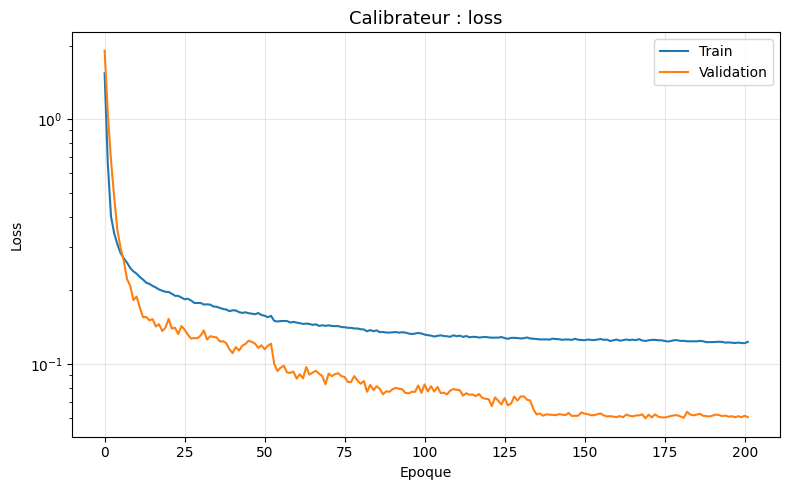

In [351]:
fig, ax = plt.subplots(figsize=(8, 5))  
ax.plot(history_calib.history['loss'], label='Train', linewidth=1.5)  
ax.plot(history_calib.history['val_loss'], label='Validation', linewidth=1.5)
ax.set_title('Calibrateur : loss', fontsize=13)  
ax.set_xlabel('Epoque')  
ax.set_ylabel('Loss')  
ax.set_yscale('log')  
ax.grid(True, alpha=0.3) 
ax.legend()  
plt.tight_layout()
plt.show()  


Les courbes train et validation descendent ensemble, le reseau generalise correctement. 

## MAE du calibrateur

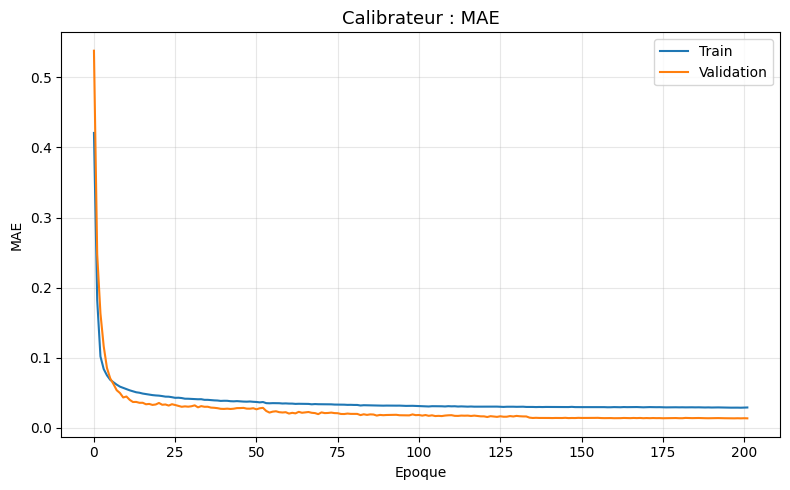

In [352]:
fig, ax = plt.subplots(figsize=(8, 5))  
ax.plot(history_calib.history['mae'], label='Train', linewidth=1.5) 
ax.plot(history_calib.history['val_mae'], label='Validation', linewidth=1.5)
ax.set_title('Calibrateur : MAE', fontsize=13)  
ax.set_xlabel('Epoque')  
ax.set_ylabel('MAE')  
ax.grid(True, alpha=0.3) 
ax.legend()
plt.tight_layout()  
plt.show()  


La MAE permet de lire plus directement la precision moyenne sur les parametres. Une baisse reguliere est un bon signe, mais une MAE trop basse n'a de sens que si la surface repricee reste fidele.

## Loss du générateur

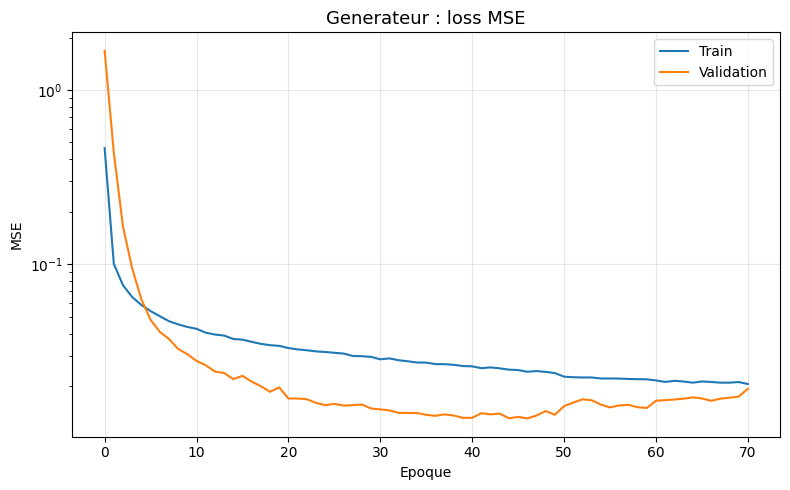

In [353]:
fig, ax = plt.subplots(figsize=(8, 5))  
ax.plot(history_gen.history['loss'], label='Train', linewidth=1.5)  
ax.plot(history_gen.history['val_loss'], label='Validation', linewidth=1.5)
ax.set_title('Generateur : loss MSE', fontsize=13)  
ax.set_xlabel('Epoque')  
ax.set_ylabel('MSE')  
ax.set_yscale('log')  
ax.grid(True, alpha=0.3) 
ax.legend()  
plt.tight_layout()
plt.show()  


Le generateur est plus proche d'un probleme direct. On attend donc souvent une convergence plus lisse que pour le calibrateur.

## MAE du générateur

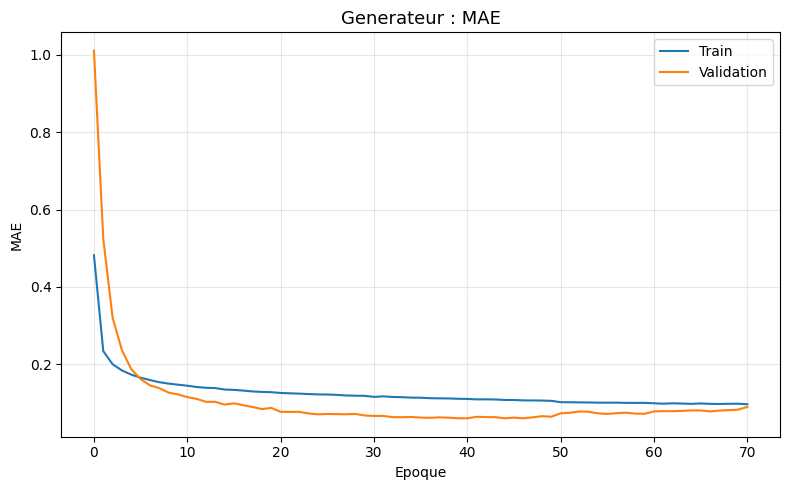

In [354]:
fig, ax = plt.subplots(figsize=(8, 5))  
ax.plot(history_gen.history['mae'], label='Train', linewidth=1.5)  
ax.plot(history_gen.history['val_mae'], label='Validation', linewidth=1.5)
ax.set_title('Generateur : MAE', fontsize=13)  
ax.set_xlabel('Epoque')  
ax.set_ylabel('MAE')  
ax.grid(True, alpha=0.3) 
ax.legend()  
plt.tight_layout()
plt.show()

# Evaluation sur le jeu de test

Nous commencons par mesurer la qualite de recuperation des parametres Heston sur des surfaces synthetiques jamais vues.


In [355]:
y_pred_scaled = calibration_model.predict(x_test_scaled, verbose=0)
y_pred_raw = unscale_params(y_pred_scaled)  # fixe y_pred brut
y_true = params_test  # fixe y true


In [356]:
def project_heston_params_batch(param_matrix): 
    """
    Projette un ensemble de parametres dans le domaine admissible de
    Heston.
    """
    projected = []
    for params in np.atleast_2d(param_matrix):
        v0, rho, sigma, theta, kappa = params
        v0 = np.clip(v0, *bounds['v0'])
        rho = np.clip(rho, *bounds['rho'])
        theta = np.clip(theta, *bounds['theta'])
        kappa = np.clip(kappa, *bounds['kappa'])
        sigma_cap = np.sqrt(max(2 * kappa * theta, 1e-10)) * 0.995
        sigma = np.clip(min(sigma, sigma_cap), *bounds['sigma'])
        projected.append([v0, rho, sigma, theta, kappa])
    return np.array(projected)

y_pred = project_heston_params_batch(y_pred_raw)


In [357]:
header = (  
    f"{'Parametre':>10s} {'True (moy)':>12s} {'Pred (moy)':>12s} "
    f"{'MAE':>10s} {'RMSE':>10s} {'Err. Rel. %':>12s}"
)
row_template = (  
    "{name:>10s} {true_mean:>12.6f} {pred_mean:>12.6f} "
    "{mae:>10.6f} {rmse:>10.6f} {rel_err:>11.2f}%"
)

for i, name in enumerate(param_order):  # parcourt parametres
    true_vals = y_true[:, i]  # valeurs vraies
    pred_vals = y_pred[:, i]  # valeurs predites
    mae = np.mean(np.abs(true_vals - pred_vals))  # mae
    rmse = np.sqrt(np.mean((true_vals - pred_vals) ** 2))  # rmse
    rel_err = np.mean(  # erreur relative
        np.abs(true_vals - pred_vals) / (np.abs(true_vals) + 1e-10)
    ) * 100
    print(  # ligne resume
        row_template.format(
            name=name,
            true_mean=np.mean(true_vals),
            pred_mean=np.mean(pred_vals),
            mae=mae,
            rmse=rmse,
            rel_err=rel_err,
        )
    )

        v0     0.083097     0.082920   0.000652   0.000901        0.81%
       rho    -0.779797    -0.780564   0.007655   0.010445        1.10%
     sigma     0.339388     0.336640   0.005501   0.008106        1.66%
     theta     0.067583     0.067417   0.001011   0.001600        1.96%
     kappa     1.765663     1.765907   0.066462   0.104207        5.65%


Cette vue mesure la precision du DNN dans l'espace des parametres. Elle est utile, mais elle ne suffit pas encore a juger la qualite de la calibration : la bonne question reste la fidelite de la surface repricee.

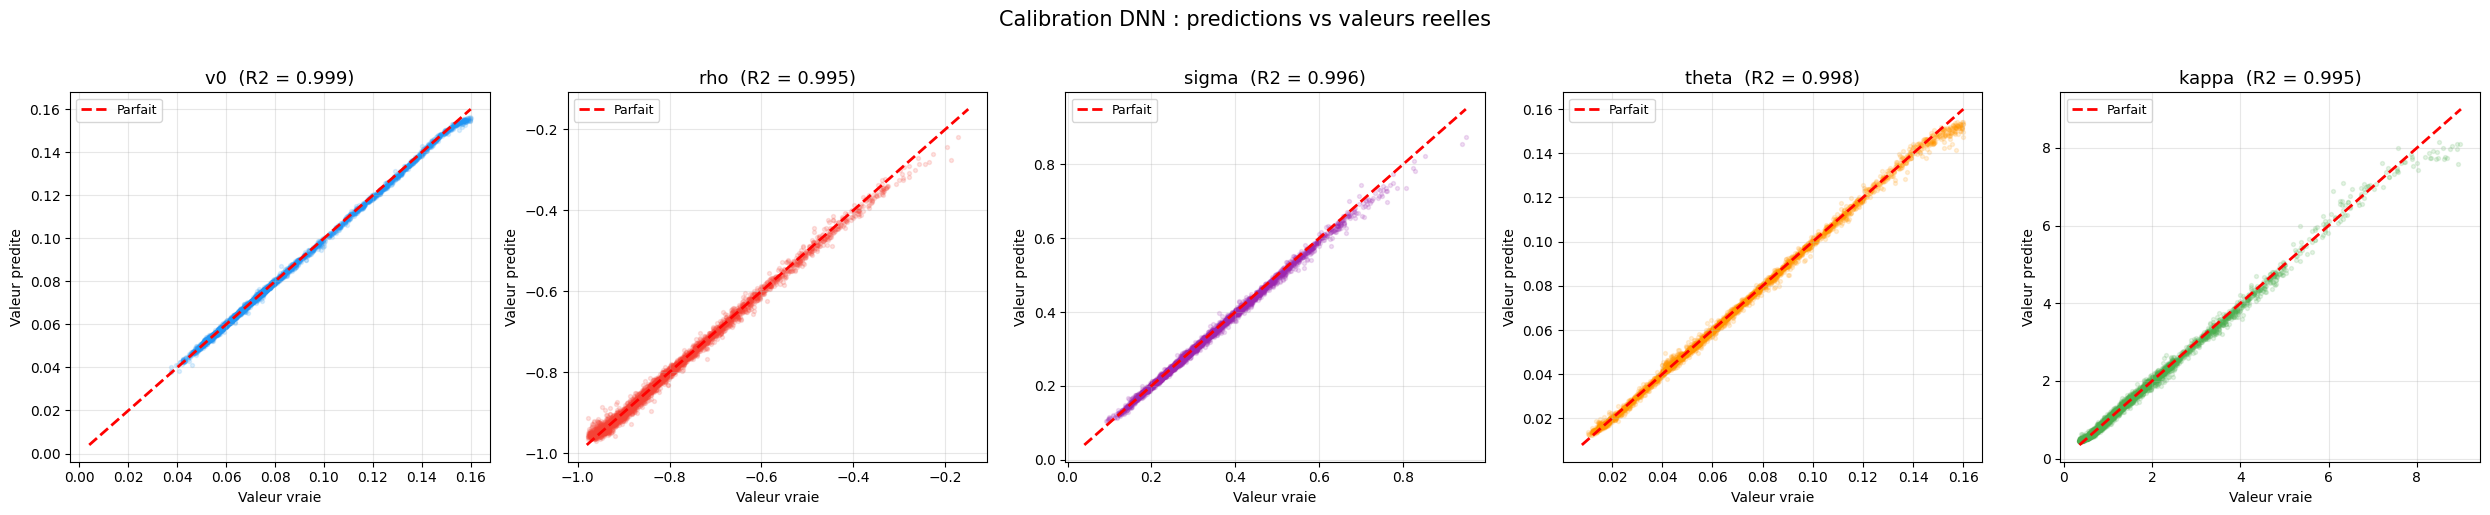

In [358]:
fig, axes = plt.subplots(1, 5, figsize=(25, 5)) 
colors = ['#2196F3', '#F44336', '#9C27B0', '#FF9800', '#4CAF50']

for i, (name, ax, color) in enumerate(zip(param_order, axes, colors)):
    true_vals = y_true[:, i]  
    pred_vals = y_pred[:, i]  
    ax.scatter(true_vals, pred_vals, alpha=0.15, s=8, color=color)  
    lo, hi = bounds[name]  
    ax.plot([lo, hi], [lo, hi], 'r--', linewidth=2, label='Parfait') 
    ss_res = np.sum((true_vals - pred_vals)**2)  # fixe ss res
    ss_tot = np.sum((true_vals - np.mean(true_vals))**2)  # fixe ss tot
    r2 = 1 - ss_res / (ss_tot + 1e-10)  # fixe r2
    ax.set_title(f'{name}  (R2 = {r2:.3f})', fontsize=13)
    ax.set_xlabel('Valeur vraie')  
    ax.set_ylabel('Valeur predite')
    ax.grid(True, alpha=0.3)  
    ax.legend(fontsize=9)  

plt.suptitle(  
    'Calibration DNN : predictions vs valeurs reelles',  
    fontsize=15,  
    y=1.02,  
)
plt.tight_layout() 
plt.show()  


Bien que les résultats soient plutôt bons, on note de leger biais dans les prédictions. On note que:

- un biais sur `v0` ou `theta` se traduira souvent par un decalage de niveau sur les smiles ;
- un biais sur `rho` alterera surtout l'asymetrie gauche-droite ;
- un biais sur `sigma` modifiera la courbure ;
- un biais sur `kappa` apparaitra plutot sur la structure par terme.


# Validation par repricing Heston

L'évaluation de la précision paramétrique (l'écart absolu entre les vrais paramètres et ceux prédits par le réseau) constitue un premier indicateur d'apprentissage, mais elle est insuffisante pour juger de la qualité du calibrateur. En raison de la forte non-linéarité du modèle de Heston, une infime erreur sur un paramètre très sensible (comme $v_0$ ou $\theta$) peut déformer drastiquement la surface, tandis qu'un écart sur un paramètre moins critique n'aura qu'un impact marginal.

La véritable validation de notre calibrateur est donc d'ordre financière: elle consiste à isoler les cinq paramètres prédits par le DNN sur le jeu de test et à les réinjecter dans le pricer semi-analytique de Heston pour recalculer intégralement la surface de volatilité implicite. 

Cette étape de repricing s'avère bien plus rigoureuse et informative que l'évaluation du générateur seul. En calculant l'erreur absolue moyenne (MAE) point par point entre la surface originelle et la surface "repricée", nous mesurons directement si les paramètres générés par le réseau permettent de reproduire une surface de volatilité implicite qui a du sens et qui reste cohérente avec les équations de la dynamique de Heston.

In [359]:
t0 = time.time()  # fixe t0
surfaces_pred_repriced = np.array([  # fixe surfaces pred
    compute_iv_surface(v0, kappa, theta, sigma, rho) 
    for v0, rho, sigma, theta, kappa in y_pred  
])
t_reprice_test = time.time() - t0  # fixe t reprice test
surface_point_mae = np.mean(  # fixe surface point
    np.abs(surfaces_test - surfaces_pred_repriced),  
    axis=1, 
)


In [360]:
print('=' * 60)  
print('REPRICING HESTON SUR LE JEU DE TEST') 
print('=' * 60)  
print(f'Temps de repricing total      : {t_reprice_test:.2f} s') 
print(f'Surface MAE moyenne           : {surface_point_mae.mean():.6f}')
print(f'Surface MAE mediane           : {np.median(surface_point_mae):.6f}')
print(f'Surface MAE maximale          : {surface_point_mae.max():.6f}')


REPRICING HESTON SUR LE JEU DE TEST
Temps de repricing total      : 15.26 s
Surface MAE moyenne           : 0.001836
Surface MAE mediane           : 0.001446
Surface MAE maximale          : 0.017548


# Smiles de volatilité

Tracer les courbes de volatilité implicite en fonction du moneyness ($K/S_0$) à maturité fixée constitue un diagnostic visuel naturel pour évaluer les forces et les limites de notre modèle. Si les métriques d'erreur globales (comme la MAE ou la RMSE) quantifient la précision moyenne du réseau, les graphiques de smiles permettent de comprendre précisément où et pourquoi le calibrateur se trompe.

Concrètement, la superposition des smiles*cibles et de ceux générés par notre pipeline (DNN puis pricer Heston) nous indique instantanément quel paramètre de la dynamique stochastique est le mieux (ou le moins bien) appris par le réseau :

- Le niveau global: Un décalage vertical assez uniforme entre la courbe prédite et la courbe cible traduit généralement un biais dans l'estimation du niveau de variance (piloté par $v_0$ ou $\theta$).
- l'asymétrie: Une pente mal reproduite ou déséquilibrée entre l'aile gauche et l'aile droite renvoie le plus souvent à une difficulté du réseau à ajuster le paramètre de corrélation $\rho$.
- La courbure: Une convexité trop prononcée ou trop plate autour de la monnaie (ATM) signale un mauvais calibrage de la volatilité de la volatilité $\sigma$.


In [361]:
atm_idx = len(moneyness_levels) // 2  # fixe atm idx
ranked_idx = np.argsort(surface_point_mae)  # fixe ranked idx
representative_indices = (  # fixe representative
    [ranked_idx[0], ranked_idx[len(ranked_idx) // 2], ranked_idx[-1]]  
)
representative_labels = (  # fixe representative
    ['Cas le mieux calibre', 'Cas median', 'Cas le plus difficile']  
)
maturity_ids = [0, 2, 4, 7]  # fixe maturity ids


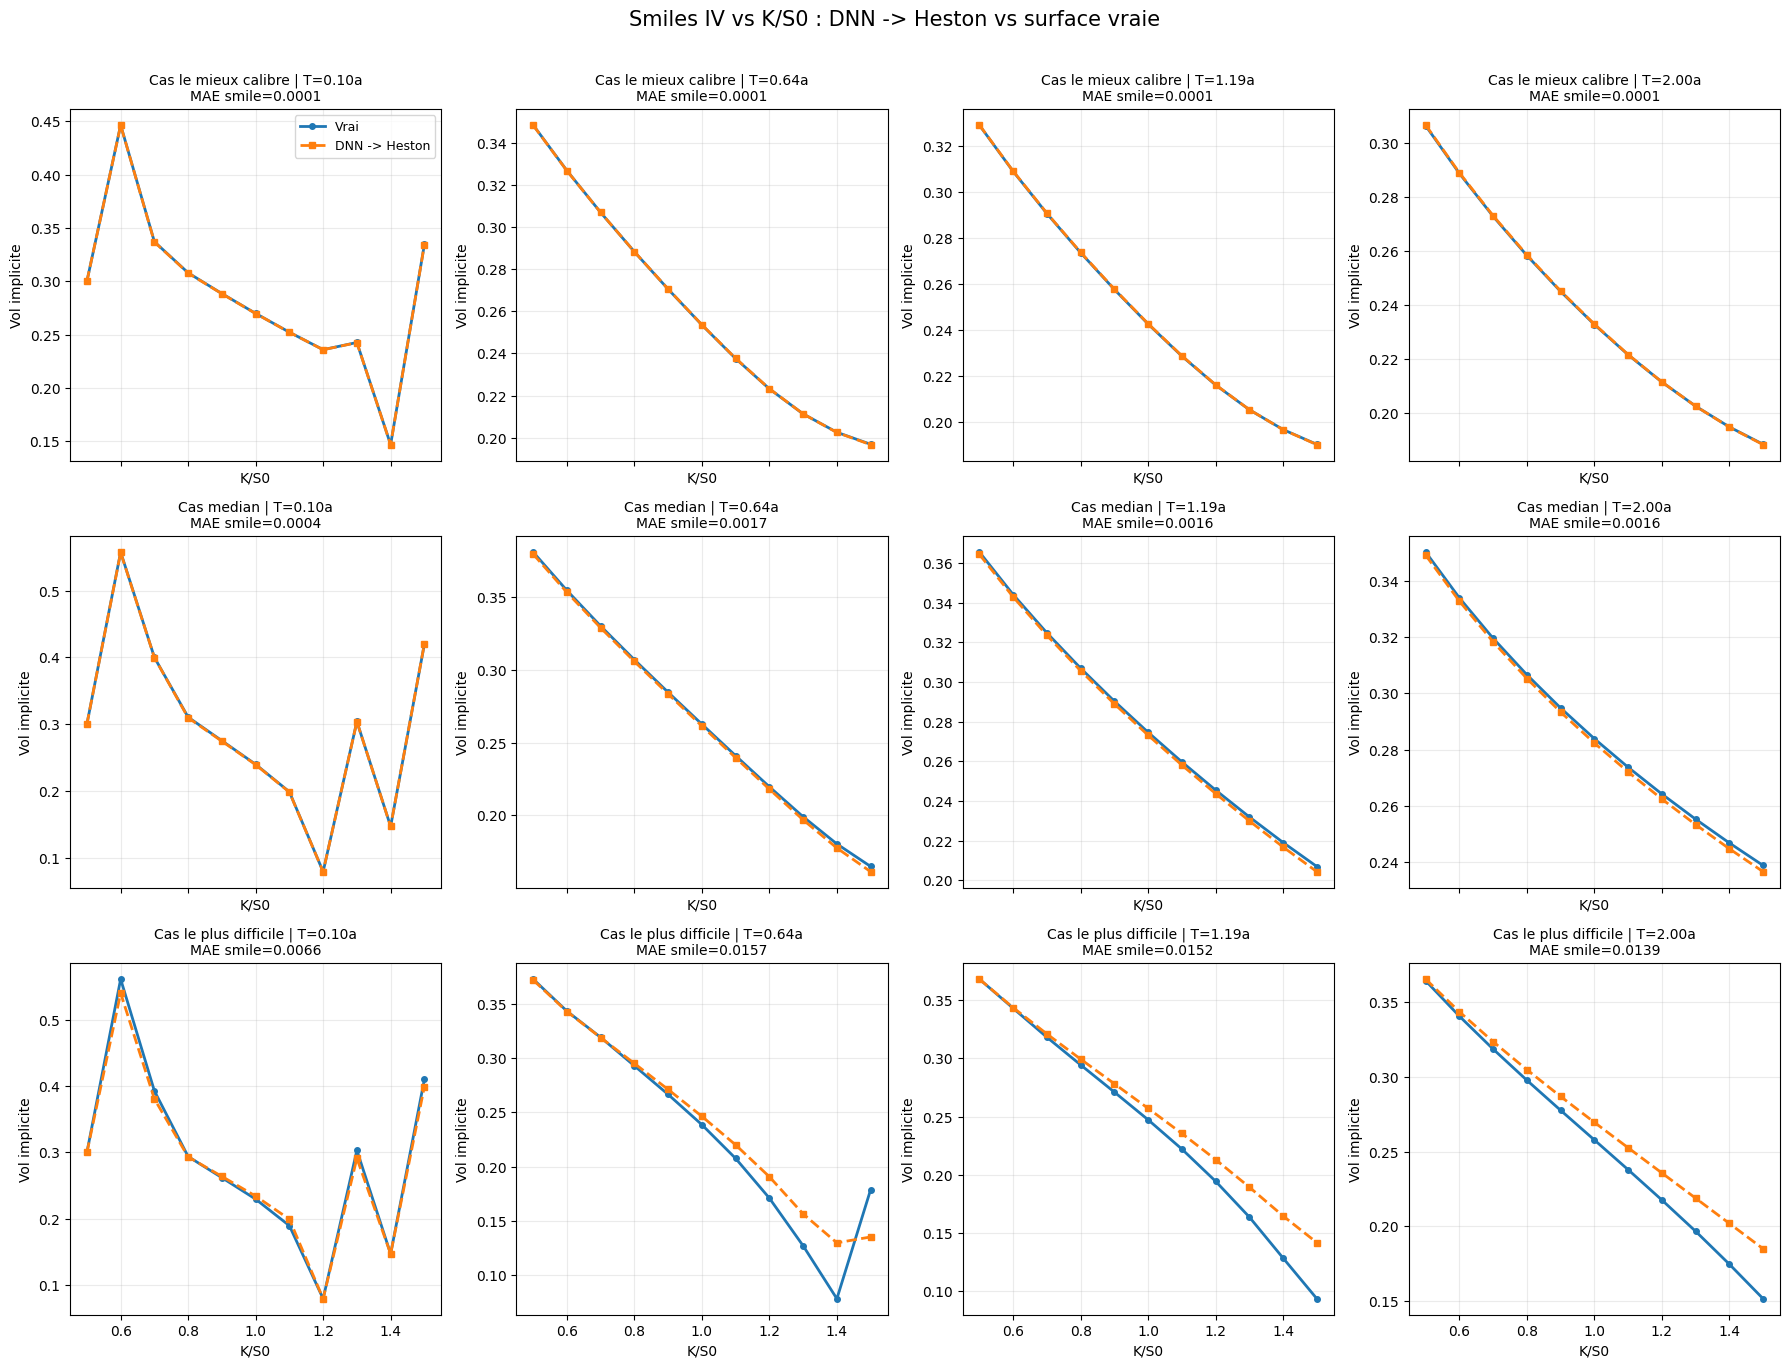

In [362]:
fig, axes = plt.subplots(  # grille comp.
    len(representative_indices),
    len(maturity_ids),
    figsize=(18, 4.5 * len(representative_indices)),
    sharex=True,
)
axes = np.atleast_2d(axes)  # axes
representative_rows = zip(representative_indices, representative_labels)

for row_id, (row_idx, row_label) in enumerate(representative_rows):
    true_surface = surfaces_test[row_idx].reshape(  # vraie surface
        len(maturities),
        len(moneyness_levels),
    )
    pred_surface = surfaces_pred_repriced[row_idx].reshape(
        len(maturities),
        len(moneyness_levels),
    )

    for col_id, maturity_idx in enumerate(maturity_ids):  # parcourt maturites
        ax = axes[row_id, col_id]  # sous-graphe
        iv_true = true_surface[maturity_idx]  # vrai smile
        iv_pred = pred_surface[maturity_idx]  # smile predit
        smile_mae = np.mean(np.abs(iv_true - iv_pred))  # mae smile
        ax.plot(  # trace vrai smile
            moneyness_levels,
            iv_true,
            'o-',
            linewidth=2,
            markersize=4,
            label='Vrai',
        )
        ax.plot(  # trace smile predit
            moneyness_levels,
            iv_pred,
            's--',
            linewidth=2,
            markersize=4,
            label='DNN -> Heston',
        )
        title = (  # titre graphe
            f'{row_label} | T={maturities[maturity_idx]:.2f}a\n'
            f'MAE smile={smile_mae:.4f}'
        )
        ax.set_title(title, fontsize=10)  # titre graphe
        ax.set_xlabel('K/S0')  # axe x
        ax.set_ylabel('Vol implicite')  # axe y
        ax.grid(True, alpha=0.25)  # grille
        if row_id == 0 and col_id == 0:  # une legende
            ax.legend(fontsize=9)  # legende

plt.suptitle(  
    'Smiles IV vs K/S0 : DNN -> Heston vs surface vraie',
    fontsize=15,
    y=1.01,
)
plt.tight_layout() 
plt.show() 

# Validation sur données de marché 

Nous effectuons ici un test du calibrateur sur une vraie surface de volatilité implicite obtenue via `yfinance` pour le ticker QQQ. 

Nous ne nous attendons pas à des résultats exceptionnels pour cette étape. En effet, le modèle a été entraîné sur des surfaces de volatilité "parfaites", alors qu'ici nous sommes contraints d'interpoler une surface de marché réelle, avec toutes les irrégularités que cela implique.

Le réseau entraîné est gelé : il reçoit une seule fois une représentation interpolée de la surface observée, uniquement parce que son entrée attend une grille fixe `(moneyness, maturité)`. L'évaluation finale, elle, se fait exclusivement sur les quotes brutes observées.

In [409]:
ticker_symbol = 'GLD'  # fixe ticker symbol
print(f'Recuperation des donnees pour {ticker_symbol}...')  
ticker = yf.Ticker(ticker_symbol)  # fixe ticker
spot = ticker.history(period='1d')['Close'].iloc[-1]  # fixe spot
expirations = ticker.options  # fixe expirations
print(f'Prix spot actuel : {spot:.2f}')  
print(f'Maturites disponibles : {len(expirations)}') 


Recuperation des donnees pour GLD...
Prix spot actuel : 461.28
Maturites disponibles : 29


## Collecte et filtrage des quotes observees

Nous retenons uniquement des calls suffisamment liquides, avec bid et ask strictement positifs, un spread relatif raisonnable, une volatilite implicite exploitable et un domaine `(K/S, T)` compatible avec la grille sur laquelle le DNN a ete entraine.


In [410]:
market_data = []  # fixe donnees marche

for exp in expirations:  
    chain = ticker.option_chain(exp)  # fixe chain
    calls = chain.calls.copy()  # fixe calls
    calls = calls[(calls['bid'] > 0) & (calls['ask'] > 0)].copy()  # fixe calls
    if len(calls) < 3:  # filtre
        continue  # saute

    exp_date = datetime.strptime(exp, '%Y-%m-%d')  # fixe exp date
    maturity = max((exp_date - datetime.now()).days / 365.25, 1e-4)
    if maturity <= 0.05 or maturity >= 1.8:  # filtre
        continue  # saute

    for _, row in calls.iterrows(): 
        strike = float(row['strike'])  # fixe strike
        bid = float(row['bid'])  # fixe bid
        ask = float(row['ask'])  # fixe ask
        mid_price = 0.5 * (bid + ask)  # fixe prix median
        spread = ask - bid  # fixe spread
        rel_spread = spread / max(mid_price, 1e-8)  # fixe rel spread
        iv = row.get('impliedVolatility', None)  # fixe iv
        volume = float(row.get('volume', 0) or 0)  # fixe volume
        open_interest = float(row.get('openInterest', 0) or 0)
        moneyness = strike / spot  # fixe moneyness

        if iv is None or pd.isna(iv):  # filtre
            continue  # saute
        if not (0.75 <= moneyness <= 1.25):  # filtre
            continue  # saute
        if not (0.02 < float(iv) < 1.2):  # filtre
            continue  # saute
        if rel_spread >= 0.40:  # filtre
            continue  # saute
        if volume <= 0 and open_interest <= 50:  # filtre
            continue  # saute
        if not (0.0 < mid_price < spot):  # filtre
            continue  # saute

        market_data.append({  
            'maturity': maturity,
            'strike': strike,  
            'moneyness': moneyness,
            'bid': bid,  
            'ask': ask,  
            'mid_price': mid_price,  
            'iv': float(iv),  
            'volume': volume, 
            'open_interest': open_interest,  
            'spread': spread,  
            'rel_spread': rel_spread,  
        })


In [411]:
df_market = (  # dataframe marche
    pd.DataFrame(market_data)
    .sort_values(['maturity', 'moneyness'])
    .reset_index(drop=True)
)
if df_market.empty:  # verifie non vide
    raise ValueError(
        "Aucune donnee de marche exploitable n'a ete collectee "
        f"pour {ticker_symbol}."
    )
if df_market['maturity'].nunique() < 3:  # verifie maturites
    raise ValueError(
        "Le test de marche requiert au moins 4 maturites liquides "
        "distinctes dans le domaine du reseau."
    )

moneyness_min = df_market['moneyness'].min()  # min moneyness
moneyness_max = df_market['moneyness'].max()  # max moneyness
maturity_min = df_market['maturity'].min()  # maturite min
maturity_max = df_market['maturity'].max()  # maturite max


print(f"Quotes retenues              : {len(df_market)}")  # total
print(f"Maturites distinctes         : {df_market['maturity'].nunique()}")
print(  # plage moneyness
    f"Plage de moneyness           : "
    f"[{moneyness_min:.3f}, {moneyness_max:.3f}]"
)
print(  # plage maturite
    f"Plage de maturite            : "
    f"[{maturity_min:.3f}, {maturity_max:.3f}] ans"
)
print(  # resume du spread
    f"Spread relatif median        : {df_market['rel_spread'].median():.2%}"
)


Quotes retenues              : 69
Maturites distinctes         : 8
Plage de moneyness           : [0.750, 0.930]
Plage de maturite            : [0.162, 0.791] ans
Spread relatif median        : 2.99%


# Construction de la surface de volatilité

Nous interpolons la surface sur la grille standard d'entrainement. Pour stabiliser l'interpolation, nous travaillons sur la variance totale plutot que directement sur la volatilite implicite.


In [412]:
market_points = df_market[['moneyness', 'maturity']].values
market_total_variance = (  # variances totales
    (df_market['iv'].values ** 2) * df_market['maturity'].values
)

m_grid, t_grid = np.meshgrid(moneyness_levels, maturities)  # grille
grid_points = np.column_stack([m_grid.ravel(), t_grid.ravel()])  # grille

tv_interpolated = griddata(  # interpolate total variance
    market_points,
    market_total_variance,
    grid_points,
    method='linear',
)
mask_nan = np.isnan(tv_interpolated)  # valeurs manqu.
if mask_nan.any():  # comble trous
    tv_nearest = griddata(
        market_points,
        market_total_variance,
        grid_points,
        method='nearest',
    )  # voisin proche
    tv_interpolated[mask_nan] = tv_nearest[mask_nan]  # remplace noeuds

iv_interpolated = np.sqrt(  # vols interp.
    np.maximum(tv_interpolated, 1e-10) / np.maximum(grid_points[:, 1], 1e-10)
)
market_input_surface = np.clip(  # borne surface
    iv_interpolated.reshape(len(maturities), len(moneyness_levels)),
    0.01,
    1.0,
)

print(  # shape entree
    f"Surface d'entree interpolee : {market_input_surface.shape}"
)
print(  # min max vol
    f"IV min = {market_input_surface.min():.4f}, "
    f"max = {market_input_surface.max():.4f}"
)


Surface d'entree interpolee : (8, 11)
IV min = 0.2101, max = 0.9815


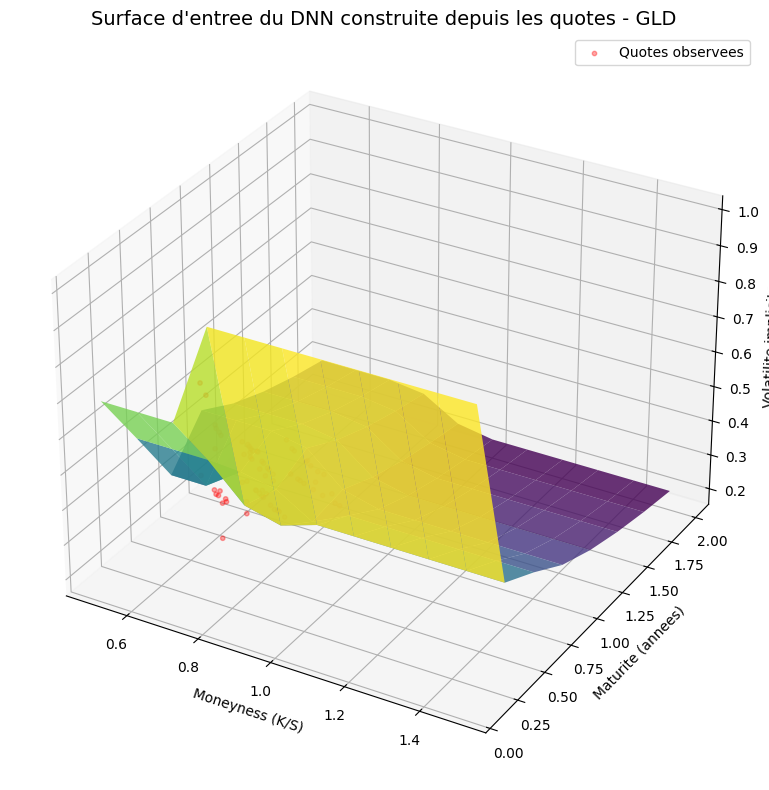

In [413]:
fig = plt.figure(figsize=(12, 8))  # fixe fig
ax = fig.add_subplot(111, projection='3d')  # fixe ax
ax.plot_surface(  
    m_grid,  
    t_grid,  
    market_input_surface,  
    cmap='viridis',  
    alpha=0.8,  
)
ax.scatter(  
    df_market['moneyness'],  
    df_market['maturity'],  
    df_market['iv'],  
    color='red',  
    s=10,  
    alpha=0.35,  
    label='Quotes observees',  
)
ax.set_xlabel('Moneyness (K/S)')
ax.set_ylabel('Maturite (annees)')
ax.set_zlabel('Volatilite implicite')
ax.set_title(  
    f"Surface d'entree du DNN construite depuis les quotes - {ticker_symbol}",
    fontsize=14, 
)
ax.legend()  
plt.tight_layout()  
plt.show()  


## Pré-traitement

Nous reprenons ici la meme logique que pour la validation synthétique. La surface implicite de marche est d'abord reconstruite sur la grille du notebook, puis elle est envoyee une seule fois dans le DNN. Les parametres predits sont enfin reinjectes dans le pricer Heston pour comparer directement la surface de marche interpolee et la surface Heston repricée.


In [414]:
market_input_flat = market_input_surface.flatten()  # fixe entree marche f
market_input_scaled = np.clip(  # fixe entree marche s
    (market_input_flat - surface_mean) / (surface_std + 1e-8),  
    -5.0, 
    5.0,  
)

t0 = time.time()  # fixe t0
params_market_scaled = calibration_model.predict(  # fixe params marche
    market_input_scaled.reshape(1, -1),  
    verbose=0,  
)
t_dnn = (time.time() - t0) * 1000  # fixe t dnn
params_market_dnn_raw = unscale_params(params_market_scaled).flatten()
print(f'Inference DNN obtenue en {t_dnn:.2f} ms')  


Inference DNN obtenue en 19.88 ms


In [415]:
def project_heston_params(params):
    """Projette les parametres dans le domaine admissible de Heston."""
    params = np.clip(np.asarray(params, dtype=float), param_mins, param_maxs)
    v0, rho, sigma, theta, kappa = params  # deballe parametres
    sigma_cap = np.sqrt(max(2 * kappa * theta, 1e-10)) * 0.995  # borne sigma
    sigma = np.clip(min(sigma, sigma_cap), *bounds['sigma'])
    return np.array(  # params projetes
        [
            np.clip(v0, *bounds['v0']),
            np.clip(rho, *bounds['rho']),
            sigma,
            np.clip(theta, *bounds['theta']),
            np.clip(kappa, *bounds['kappa']),
        ]
    )


def summarise_market_surface_fit(
    label,
    params,
    market_surface_vector,
    model_surface_vector,
):
    """Affiche les metriques de fit sur la surface de marche interpolee."""
    market_surface_matrix = market_surface_vector.reshape(
        len(maturities),
        len(moneyness_levels),
    )
    model_surface_matrix = model_surface_vector.reshape(
        len(maturities),
        len(moneyness_levels),
    )
    surface_abs_error = np.abs(  # erreurs absolues
        market_surface_matrix - model_surface_matrix
    )
    atm_idx = len(moneyness_levels) // 2  # colonne atm
    atm_abs_error = np.abs(  # erreurs atm
        market_surface_matrix[:, atm_idx] - model_surface_matrix[:, atm_idx]
    )
    v0_val, rho_val, sigma_val, theta_val, kappa_val = params  # deballe params
    feller = 2 * kappa_val * theta_val - sigma_val**2  # ecart Feller
    surface_rmse = np.sqrt(np.mean(surface_abs_error**2))
    atm_mape = np.mean(  # mape atm
        atm_abs_error / (market_surface_matrix[:, atm_idx] + 1e-10)
    ) * 100

    print(label) 
    for name, value in zip(param_order, params):  # parcourt params
        print(f'  {name:>6s} = {value:.6f}')  # un param
    print(f'  Feller       : {feller:.6f}')  # ecart Feller
    print(f'  Surface MAE  : {surface_abs_error.mean():.6f}')  # mae
    print(f'  Surface RMSE : {surface_rmse:.6f}')  # rmse
    print(f'  ATM MAE      : {atm_abs_error.mean():.6f}')  # mae atm
    print(f'  ATM MAPE     : {atm_mape:.2f}%')  # mape atm


def heston_iv_curve(params, maturity, moneyness_grid, spot, r=risk_free_rate):
    """Construit un smile Heston sur une grille dense de moneyness."""
    v0, rho, sigma, theta, kappa = project_heston_params(params)
    prices_normalized = heston_call_prices_vec(  # tarifie la grille
        moneyness_grid,
        maturity,
        v0,
        kappa,
        theta,
        sigma,
        rho,
        r=r,
    )
    prices = spot * prices_normalized  # reechelle prix
    strikes = spot * moneyness_grid  # reechelle strikes
    return newton_iv(prices, spot, strikes, maturity, r)  # retrouve vols


Comme sur le jeu synthetique, le DNN attend une surface de taille fixe. L'interpolation n'est donc pas un post-traitement destine a aider artificiellement la calibration : elle sert uniquement a reconstruire l'objet d'entree sur la grille `(MONEYNESS, MATURITIES)`. La validation principale se fait ensuite exactement comme sur le synthétique, par repricing Heston de la surface predite et comparaison visuelle des smiles et de la surface.

In [416]:
params_market_dnn = project_heston_params(params_market_dnn_raw)
surface_market_heston = compute_iv_surface(  # fixe surface marche
    params_market_dnn[0],  
    params_market_dnn[4],  
    params_market_dnn[3],  
    params_market_dnn[2],  
    params_market_dnn[1],  
)
surface_market_heston_2d = surface_market_heston.reshape(
    len(maturities),  
    len(moneyness_levels),
)
market_surface_vector = market_input_surface.flatten()  # fixe surface marche
market_surface_2d = market_input_surface.copy()  # fixe surface marche
surface_market_abs_error = np.abs(market_surface_2d - surface_market_heston_2d)


In [417]:
print(f'Inference DNN             : {t_dnn:.2f} ms')  
summarise_market_surface_fit(  
    'Surface marche -> DNN -> repricing Heston',  
    params_market_dnn,  
    market_surface_vector,  
    surface_market_heston, 
)


Inference DNN             : 19.88 ms
Surface marche -> DNN -> repricing Heston
      v0 = 0.160000
     rho = -0.792530
   sigma = 0.115473
   theta = 0.021378
   kappa = 3.842283
  Feller       : 0.150946
  Surface MAE  : 0.142089
  Surface RMSE : 0.216903
  ATM MAE      : 0.126033
  ATM MAPE     : 22.99%


In [418]:
market_maturity_mae = np.mean(surface_market_abs_error, axis=1)
market_maturity_rmse = np.sqrt(  # rmse maturite
    np.mean((market_surface_2d - surface_market_heston_2d) ** 2, axis=1)
)

print('Erreurs par maturite sur la surface de marche :')  
for maturity, mae_val, rmse_val in zip(  # parcourt maturites
    maturities,
    market_maturity_mae,
    market_maturity_rmse,
):
    print(f'  T={maturity:.2f}a -> MAE={mae_val:.5f} | RMSE={rmse_val:.5f}')


Erreurs par maturite sur la surface de marche :
  T=0.10a -> MAE=0.54053 | RMSE=0.55630
  T=0.37a -> MAE=0.13345 | RMSE=0.13733
  T=0.64a -> MAE=0.09182 | RMSE=0.09779
  T=0.91a -> MAE=0.11448 | RMSE=0.12411
  T=1.19a -> MAE=0.08801 | RMSE=0.09754
  T=1.46a -> MAE=0.06942 | RMSE=0.07919
  T=1.73a -> MAE=0.05521 | RMSE=0.06549
  T=2.00a -> MAE=0.04380 | RMSE=0.05483


In [419]:
market_ranked_idx = np.argsort(market_maturity_mae)  # classe maturites
selected_market_ids = [  # maturites rep.
    market_ranked_idx[0],
    market_ranked_idx[len(market_ranked_idx) // 2],
    market_ranked_idx[-1],
]
selected_market_ids = list(dict.fromkeys(selected_market_ids))
base_market_labels = [ 
    'Smile le mieux reproduit',
    'Smile median',
    'Smile le plus difficile',
]
selected_market_labels = base_market_labels[:len(selected_market_ids)]
if len(selected_market_labels) < len(selected_market_ids):
    extra_count = len(selected_market_ids) - len(selected_market_labels)
    extra_labels = [  
        f'Smile supplementaire {k + 1}'
        for k in range(extra_count)
    ]
    selected_market_labels += extra_labels  

In [420]:
print('Maturites retenues pour les smiles de marche :')  
for label, idx in zip(selected_market_labels, selected_market_ids):
    print(  # maturite retenue
        f'  {label} -> T={maturities[idx]:.2f}a '
        f'(MAE={market_maturity_mae[idx]:.5f})'
    )


Maturites retenues pour les smiles de marche :
  Smile le mieux reproduit -> T=2.00a (MAE=0.04380)
  Smile median -> T=0.64a (MAE=0.09182)
  Smile le plus difficile -> T=0.10a (MAE=0.54053)


In [421]:
print('Surface MAE globale :', f'{surface_market_abs_error.mean():.6f}')
surface_market_rmse = np.sqrt(  # rmse globale
    np.mean((market_surface_2d - surface_market_heston_2d) ** 2)
)
print('Surface RMSE globale:', f'{surface_market_rmse:.6f}')  # rmse


Surface MAE globale : 0.142089
Surface RMSE globale: 0.216903


## Lecture des parametres calibres

Les parametres affiches ci-dessus sont ceux fournis par le DNN apres projection dans le domaine admissible de Heston. L'interpretation reste la meme que sur le jeu synthetique : `v0` et `theta` pilotent le niveau moyen de variance, `rho` l'asymetrie du smile, `sigma` sa courbure et `kappa` la vitesse de retour a la moyenne. La qualite de la calibration s'observe maintenant directement sur la superposition des surfaces et des smiles de volatilite.

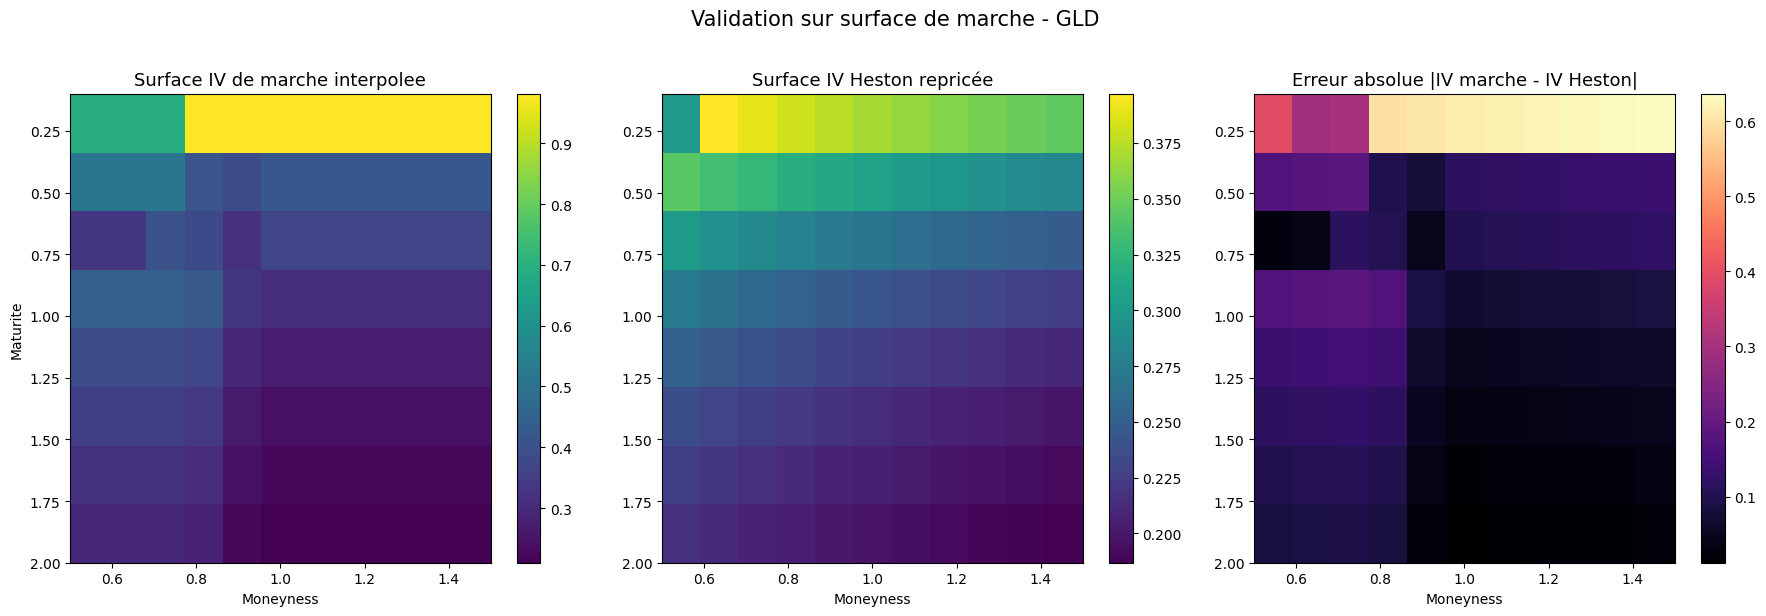

In [422]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))  # grille figure

im0 = axes[0].imshow(  # surface marche
    market_surface_2d,
    aspect='auto',
    cmap='viridis',
    extent=[
        moneyness_levels[0],
        moneyness_levels[-1],
        maturities[-1],
        maturities[0],
    ],
)
axes[0].set_title('Surface IV de marche interpolee', fontsize=13)  
axes[0].set_xlabel('Moneyness')
axes[0].set_ylabel('Maturite') 
plt.colorbar(im0, ax=axes[0])  

im1 = axes[1].imshow(  # surface Heston
    surface_market_heston_2d,
    aspect='auto',
    cmap='viridis',
    extent=[
        moneyness_levels[0],
        moneyness_levels[-1],
        maturities[-1],
        maturities[0],
    ],
)
axes[1].set_title('Surface IV Heston repricée', fontsize=13)  
axes[1].set_xlabel('Moneyness')  # axe x
plt.colorbar(im1, ax=axes[1])  # barre couleur

im2 = axes[2].imshow(  # erreur absolue
    surface_market_abs_error,
    aspect='auto',
    cmap='magma',
    extent=[
        moneyness_levels[0],
        moneyness_levels[-1],
        maturities[-1],
        maturities[0],
    ],
)
axes[2].set_title('Erreur absolue |IV marche - IV Heston|', fontsize=13)
axes[2].set_xlabel('Moneyness')  # axe x
plt.colorbar(im2, ax=axes[2])  # barre couleur

plt.suptitle(  
    f'Validation sur surface de marche - {ticker_symbol}',
    fontsize=15,
    y=1.02,
)
plt.tight_layout()  
plt.show() 


## Interpretation de la comparaison de surfaces

On compare ici exactement les deux objets qui interessent le notebook : la surface de marche reconstruite sur la grille d'entree, et la surface de volatilite implicite obtenue apres passage dans le DNN puis repricing Heston. La carte d'erreur indique visuellement les zones de la surface ou le modele suit correctement le marche, et celles ou ses limites apparaissent.


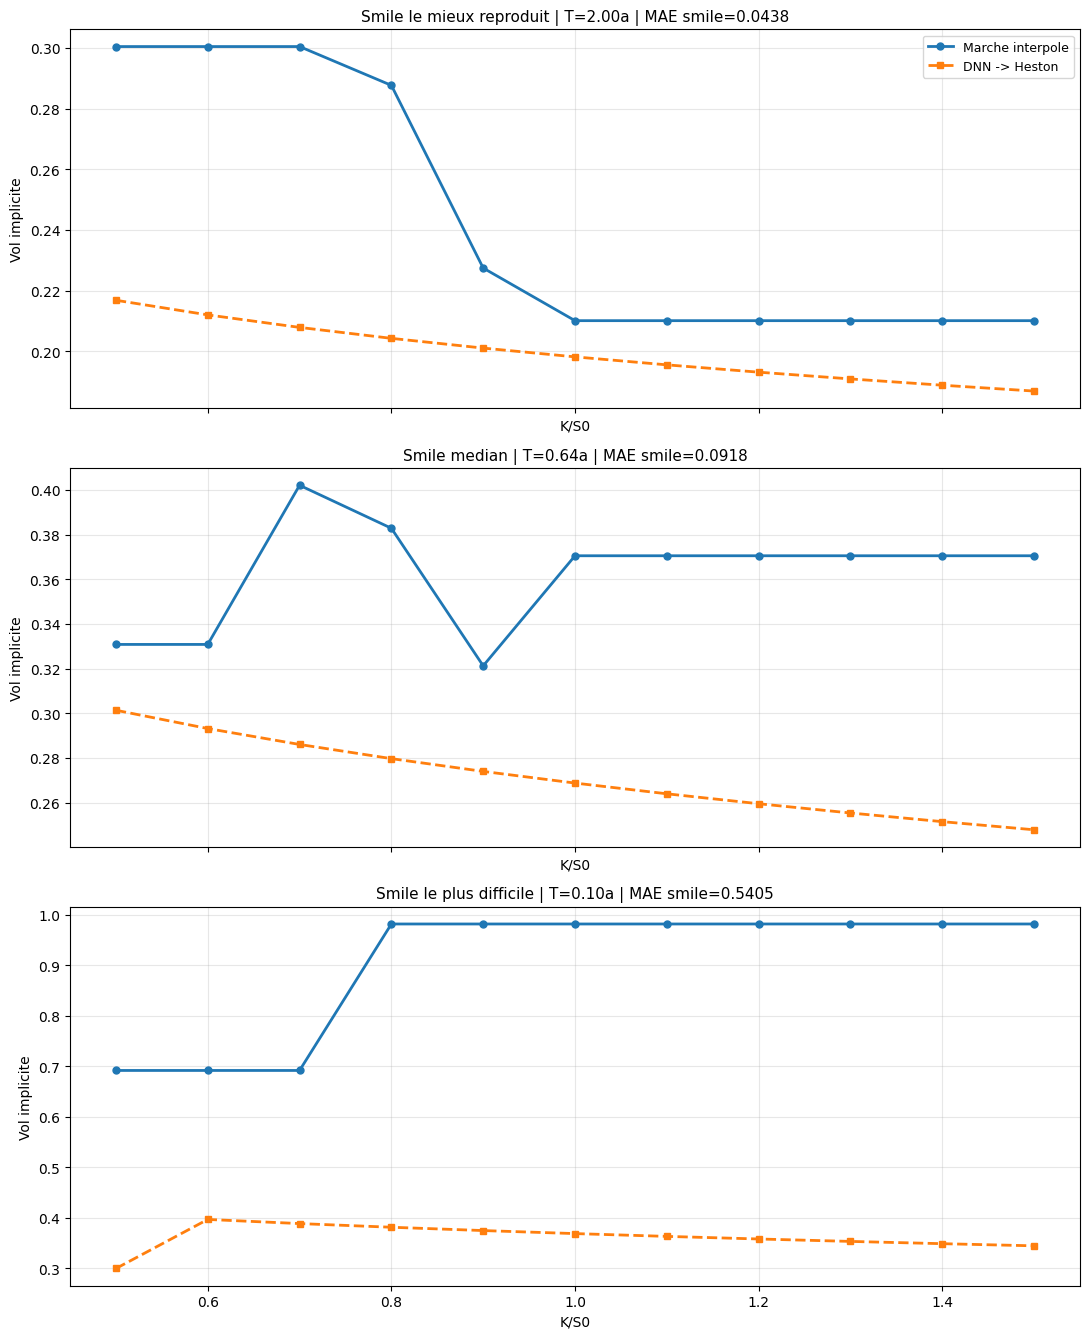

In [423]:
fig, axes = plt.subplots(  # figure smiles
    len(selected_market_ids),
    1,
    figsize=(11, 4.5 * len(selected_market_ids)),
    sharex=True,
)
axes = np.atleast_1d(axes)  # forme axes
smile_rows = zip(axes, selected_market_ids, selected_market_labels)

for ax, maturity_idx, label in smile_rows:  # smiles retenus
    market_smile = market_surface_2d[maturity_idx]  # smile marche
    heston_smile = surface_market_heston_2d[maturity_idx]
    smile_mae = np.mean(np.abs(market_smile - heston_smile))

    ax.plot(  # trace smile marche
        moneyness_levels,
        market_smile,
        'o-',
        linewidth=2,
        markersize=5,
        label='Marche interpole',
    )
    ax.plot(  # trace smile Heston
        moneyness_levels,
        heston_smile,
        's--',
        linewidth=2,
        markersize=5,
        label='DNN -> Heston',
    )
    title = (  
        f'{label} | T={maturities[maturity_idx]:.2f}a | '
        f'MAE smile={smile_mae:.4f}'
    )
    ax.set_title(title, fontsize=11)  
    ax.set_xlabel('K/S0')  # axe x
    ax.set_ylabel('Vol implicite')  # axe y
    ax.grid(True, alpha=0.3)  # grille

axes[0].legend(fontsize=9)  
plt.tight_layout()  
plt.show()  


Cette figure reproduit explicitement la logique utilisee sur les donnees synthetiques : pour quelques maturites representatives, on superpose le smile IV de marche et le smile IV du modele obtenu par la chaine `surface -> DNN -> Heston`. 

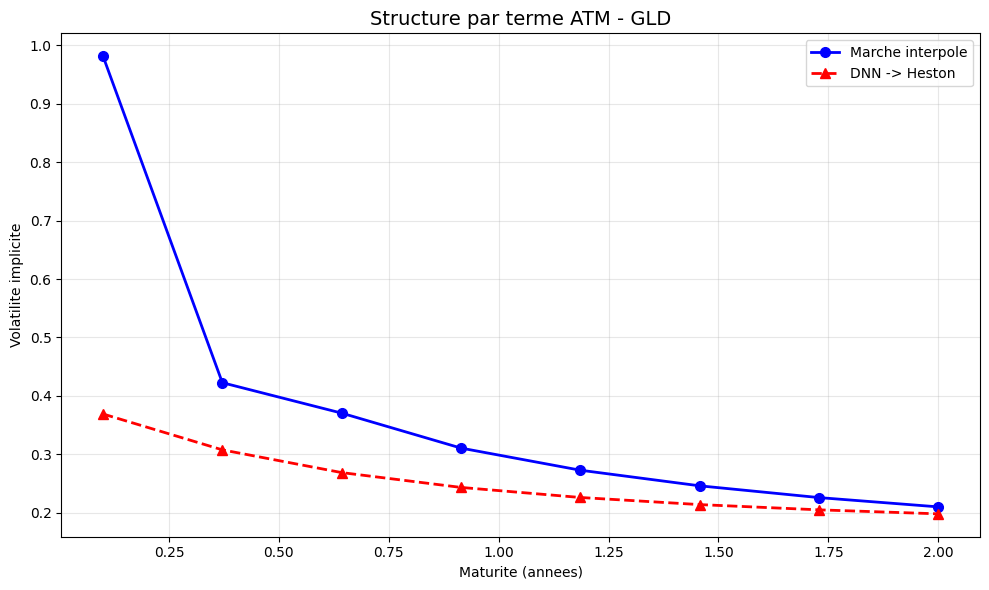

In [424]:
fig, ax = plt.subplots(figsize=(10, 6))  
atm_idx = len(moneyness_levels) // 2  # fixe atm idx
ax.plot(  
    maturities,  
    market_surface_2d[:, atm_idx],  
    'bo-',  
    linewidth=2,  
    markersize=7, 
    label='Marche interpole',  
)
ax.plot(  
    maturities,  
    surface_market_heston_2d[:, atm_idx],  
    'r^--',  
    linewidth=2,  
    markersize=7, 
    label='DNN -> Heston',  
)
ax.set_title(f'Structure par terme ATM - {ticker_symbol}', fontsize=14)
ax.set_xlabel('Maturite (annees)')  
ax.set_ylabel('Volatilite implicite')
ax.grid(True, alpha=0.3)  
ax.legend(fontsize=10)  
plt.tight_layout()  
plt.show()  


# Conclusion

Sur donnees de marche, la surface de reference n'est pas une verite exacte mais une surface reconstruite a partir de quotes parfois bruitees et incompletes. Les ecarts observes peuvent donc venir du DNN, du modele de Heston lui-meme, ou du processus de reconstruction de la surface. Cela n'empeche pas d'obtenir une validation visuelle cohérente, mais il faut garder cette difference en tete par rapport au cas synthétique.

Plusieurs prolongements sont possibles : ameliorer encore le nettoyage et l'interpolation de la surface de marche, comparer explicitement les smiles sur davantage de maturites, suivre l'evolution des parametres calibres dans le temps en archivant des snapshots `yfinance`.